## Import des modules

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Analyse Exploratoire

## 1.1 Import et observation des données

In [2]:
building_consumption = pd.read_csv("Data/2016_Building_Energy_Benchmarking.csv")

## 1.2 On regarde comment un batiment est défini dans ce jeu de données

In [3]:
building_consumption.head()

,OSEBuildingID,DataYear,BuildingType,PrimaryPropertyType,PropertyName,Address,City,State,ZipCode,TaxParcelIdentificationNumber,...,Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),DefaultData,Comments,ComplianceStatus,Outlier,TotalGHGEmissions,GHGEmissionsIntensity
0,1,2016,NonResidential,Hotel,Mayflower park hotel,405 Olive way,Seattle,WA,98101.0,0659000030,...,1.156514e+06,3946027.0,12764.52930,1276453.0,False,NaN,Compliant,NaN,249.98,2.83
1,2,2016,NonResidential,Hotel,Paramount Hotel,724 Pine street,Seattle,WA,98101.0,0659000220,...,9.504252e+05,3242851.0,51450.81641,5145082.0,False,NaN,Compliant,NaN,295.86,2.86
2,3,2016,NonResidential,Hotel,5673-The Westin Seattle,1900 5th Avenue,Seattle,WA,98101.0,0659000475,...,1.451544e+07,49526664.0,14938.00000,1493800.0,False,NaN,Compliant,NaN,2089.28,2.19
3,5,2016,NonResidential,Hotel,HOTEL MAX,620 STEWART ST,Seattle,WA,98101.0,0659000640,...,8.115253e+05,2768924.0,18112.13086,1811213.0,False,NaN,Compliant,NaN,286.43,4.67
4,8,2016,NonResidential,Hotel,WARWICK SEATTLE HOTEL (ID8),401 LENORA ST,Seattle,WA,98121.0,0659000970,...,1.573449e+06,5368607.0,88039.98438,8803998.0,False,NaN,Compliant,NaN,505.01,2.88


On regarde le nombre de valeurs manquantes par colonne ainsi que leur type

In [4]:
building_consumption.info()

<class 'pandas.DataFrame'>
RangeIndex: 3376 entries, 0 to 3375
Data columns (total 46 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   OSEBuildingID                    3376 non-null   int64  
 1   DataYear                         3376 non-null   int64  
 2   BuildingType                     3376 non-null   str    
 3   PrimaryPropertyType              3376 non-null   str    
 4   PropertyName                     3376 non-null   str    
 5   Address                          3376 non-null   str    
 6   City                             3376 non-null   str    
 7   State                            3376 non-null   str    
 8   ZipCode                          3360 non-null   float64
 9   TaxParcelIdentificationNumber    3376 non-null   str    
 10  CouncilDistrictCode              3376 non-null   int64  
 11  Neighborhood                     3376 non-null   str    
 12  Latitude                       

#### TERMINER L'ANALYSE EXPLORATOIRE

A réaliser :
- Une analyse descriptive des données, y compris une explication du sens des colonnes gardées, des arguments derrière la suppression de lignes ou de colonnes, des statistiques descriptives et des visualisations pertinentes.

Qelques pistes d'analyse :

* Identifier les colonnes avec une majorité de valeurs manquantes ou constantes en utilisant la méthode value_counts() de Pandas
* Mettre en evidence les différences entre les immeubles mono et multi-usages
* Utiliser des pairplots et des boxplots pour faire ressortir les outliers ou des batiments avec des valeurs peu cohérentes d'un point de vue métier

## 1.3 Restriction au périmètre non résidentiel et statistiques des données brutes (avant nettoyage)

In [5]:
# On vérifie et on stocke le nombre de lignes de départ pour rappel
nb_lignes_initial = building_consumption.shape[0]
print(f"Nombre de bâtiments avant filtrage : {nb_lignes_initial}")

# Voir les types dispo dans BuildingTypes
print(building_consumption["BuildingType"].value_counts())

Nombre de bâtiments avant filtrage : 3376
BuildingType
NonResidential          1460
Multifamily LR (1-4)    1018
Multifamily MR (5-9)     580
Multifamily HR (10+)     110
SPS-District K-12         98
Nonresidential COS        85
Campus                    24
Nonresidential WA          1
Name: count, dtype: int64


In [6]:
# Je conserve uniquement ceux qui ne commencent PAS par Multifamily car il me semble que ce sont eux
# qui sont les batiments résidentiels
building_consumption = building_consumption[~building_consumption["BuildingType"].str.contains("Multifamily")]

# On voit donc l'écart
nb_lignes_apres_filtrage = building_consumption.shape[0]
print(f"Nombre de bâtiments après filtrage résidentiel : {nb_lignes_apres_filtrage}")
print(f"Lignes supprimées : {nb_lignes_initial - nb_lignes_apres_filtrage}")

Nombre de bâtiments après filtrage résidentiel : 1668
Lignes supprimées : 1708


**Statistiques descriptives des données brutes (avant nettoyage)**
On décrit d'abord le jeu tel qu'il est, pour repérer les valeurs incohérentes

In [7]:
"""Statistiques descriptives AVANT nettoyage (périmètre non résidentiel uniquement)"""
# Mêmes colonnes qu'en 1.8, pour pouvoir comparer avant / après nettoyage
# (la target est écrite en toutes lettres : la variable "target" n'est définie qu'en 1.7)
colonnes_cles_brutes = [
    "PropertyGFATotal", "PropertyGFABuilding(s)", "PropertyGFAParking",
    "NumberofFloors", "NumberofBuildings", "YearBuilt", "SiteEnergyUse(kBtu)",
]

# .T = une ligne par variable, plus lisible
stats_brutes = building_consumption[colonnes_cles_brutes].describe().T

# Deux colonnes en plus pour repérer les anomalies d'un coup d'oeil :
# - nb_zeros : un bâtiment avec 0 étage ou 0 bâtiment n'a pas de sens physique
# - nb_manquants : describe() ignore les NaN sans prévenir, on les compte à part
stats_brutes["nb_zeros"] = (building_consumption[colonnes_cles_brutes] == 0).sum()
stats_brutes["nb_manquants"] = building_consumption[colonnes_cles_brutes].isnull().sum()

stats_brutes.round(1)

,count,mean,std,min,25%,50%,75%,max,nb_zeros,nb_manquants
PropertyGFATotal,1668.0,118842.7,297362.2,11285.0,29477.8,49289.5,105325.0,9320156.0,0,0
PropertyGFABuilding(s),1668.0,105944.7,284211.6,3636.0,28475.2,47391.5,94759.8,9320156.0,0,0
PropertyGFAParking,1668.0,12898.0,42274.5,0.0,0.0,0.0,0.0,512608.0,1335,0
NumberofFloors,1668.0,4.1,6.6,0.0,1.0,2.0,4.0,99.0,16,0
NumberofBuildings,1666.0,1.2,2.9,0.0,1.0,1.0,1.0,111.0,52,2
YearBuilt,1668.0,1961.9,32.7,1900.0,1930.0,1965.0,1989.0,2015.0,0,0
SiteEnergyUse(kBtu),1666.0,8437933.2,30243803.4,0.0,1229290.8,2554947.2,6913348.5,873923712.0,16,2


In [8]:
# Inspection du bâtiment de 99 étages avant de décider quoi en faire
building_consumption[building_consumption["NumberofFloors"] == 99][
    ["PropertyName", "PrimaryPropertyType", "NumberofFloors", "PropertyGFATotal", "SiteEnergyUse(kBtu)"]
]

,PropertyName,PrimaryPropertyType,NumberofFloors,PropertyGFATotal,SiteEnergyUse(kBtu)
1359,Seattle Chinese Baptist Church,Worship Facility,99,21948,326001.1875


**Lecture des statistiques brutes (1 668 bâtiments non résidentiels, avant nettoyage)**

Plusieurs valeurs incohérentes d'un point de vue métier, qui motivent le nettoyage
- **16 bâtiments à 0 étage** et **52 à 0 bâtiment** : physiquement impossible pour un bâtiment mesuré.
- **16 bâtiments à 0 kBtu de consommation** et 2 sans valeur : un bâtiment non résidentiel en activité consomme forcément de l'énergie.
- **Valeurs extrêmes** : une surface de 9,3 M sqft et une consommation de 874 M kBtu, à surveiller dans la suite du nettoyage
- **`PropertyGFAParking` à 0 pour 1 335 bâtiments (80 %)** : ce n'est pas une anomalie, ces bâtiments n'ont simplement pas de parking.

**Cas isolé repéré : un bâtiment de 99 étages** (Seattle Chinese Baptist Church, 21 948 sqft), soit environ 20 m² par étage : erreur de saisie certaine sur le nombre d'étages.  
Après vérification sur internet, le plus haut batiment de Seattle est à 76 étages.  
Le reste de la ligne (surface, consommation, type) est cohérent

## 1.4 Suppression des colonnes sans valeur ajoutée

In [9]:
# On construit un tableau récapitulatif : une ligne par colonne du dataset
resume_colonnes = pd.DataFrame({
    "type": building_consumption.dtypes,
    "nb_valeurs_uniques": building_consumption.nunique(),
    "nb_lignes": len(building_consumption),
    "nb_manquants": building_consumption.isnull().sum(),
})

# Colonne pratique : le ratio "tx_valeurs_uniques"
# proche de 1.0 -> beaucoup de valeurs différentes
# proche de 0.0 -> peu de valeurs différentes, très similaires
resume_colonnes["tx_valeurs_uniques"] = (resume_colonnes["nb_valeurs_uniques"] / resume_colonnes["nb_lignes"]).round(3)

# Tri du plus pour repérer d'un coup d'oeil les colonnes qui ont beaucoup de valeurs uniques
resume_colonnes = resume_colonnes.sort_values("tx_valeurs_uniques", ascending=False)

resume_colonnes

,type,nb_valeurs_uniques,nb_lignes,nb_manquants,tx_valeurs_uniques
OSEBuildingID,int64,1668,1668,0,1.000
PropertyName,str,1664,1668,0,0.998
Electricity(kWh),float64,1655,1668,2,0.992
Electricity(kBtu),float64,1655,1668,2,0.992
SiteEnergyUse(kBtu),float64,1651,1668,2,0.990
Address,str,1647,1668,0,0.987
SiteEnergyUseWN(kBtu),float64,1640,1668,3,0.983
TotalGHGEmissions,float64,1594,1668,2,0.956
PropertyGFATotal,int64,1590,1668,0,0.953
TaxParcelIdentificationNumber,str,1587,1668,0,0.951


La colonne `YearsENERGYSTARCertified` ne semble pas très utile, surtout qu'on a pas mal de formats de date disparates dedans  
La colonne `Comments` est vide  
Les colonnes `City`, `State` et `DataYear` ne sont pas non plus pertinentes, et contiennent quasiment toujours la même donnée  
Même chose pour `OSEBuildingID`, `Address`, `TaxParcelIdentificationNumber`  
Pour information, je conserve la colone `PropertyName` car je pense qu'elle pourra être utile plus tard pour identifier les fonctions du batiment

In [10]:
building_consumption = building_consumption.drop(columns=["Comments", "YearsENERGYSTARCertified", "City", "State", "DataYear", "OSEBuildingID", "Address", "TaxParcelIdentificationNumber"])


## 1.5 Gestion des valeurs manquantes, conversions en numériques, normalisation, retrait de lignes inutiles

In [11]:
# On regarde aussi s'il y a des colonnes avec beaucoup de NaN
# C'est directement exprimé en pourcentage pour essayer de comprendre par la suite pourquoi certaines ont beaucoup de NaN
taux_manquants = (building_consumption.isnull().sum() / len(building_consumption) * 100).sort_values(ascending=False)
print(taux_manquants[taux_manquants > 0])

Outlier                            98.980815
ThirdLargestPropertyUseType        78.836930
ThirdLargestPropertyUseTypeGFA     78.836930
SecondLargestPropertyUseTypeGFA    48.741007
SecondLargestPropertyUseType       48.741007
ENERGYSTARScore                    34.412470
ZipCode                             0.959233
LargestPropertyUseTypeGFA           0.359712
LargestPropertyUseType              0.359712
SiteEUIWN(kBtu/sf)                  0.179856
SiteEUI(kBtu/sf)                    0.179856
SiteEnergyUseWN(kBtu)               0.179856
GHGEmissionsIntensity               0.119904
NaturalGas(therms)                  0.119904
Electricity(kWh)                    0.119904
Electricity(kBtu)                   0.119904
NaturalGas(kBtu)                    0.119904
SourceEUIWN(kBtu/sf)                0.119904
ListOfAllPropertyUseTypes           0.119904
SteamUse(kBtu)                      0.119904
SiteEnergyUse(kBtu)                 0.119904
NumberofBuildings                   0.119904
SourceEUI(

In [12]:
# Pour éviter les conflits futurs, je remplace les NaN des colonnes SecondLargestPropertyUseType et ThirdLargestPropertyUseType par du None
# Même principe pour les surfaces affectées à ces usages, mais cette fois on passe en numérique, au cas ou
building_consumption["SecondLargestPropertyUseType"] = building_consumption["SecondLargestPropertyUseType"].fillna("None")
building_consumption["ThirdLargestPropertyUseType"] = building_consumption["ThirdLargestPropertyUseType"].fillna("None")
building_consumption["SecondLargestPropertyUseTypeGFA"] = building_consumption["SecondLargestPropertyUseTypeGFA"].fillna(0)
building_consumption["ThirdLargestPropertyUseTypeGFA"] = building_consumption["ThirdLargestPropertyUseTypeGFA"].fillna(0)

# Normalisation de la casse pour éviter les doublons (ex: "North" et "NORTH" actuellement traités comme 2 quartiers différents)
# Repéré lors du feature engineering car j'avais un plantage
building_consumption["Neighborhood"] = building_consumption["Neighborhood"].str.upper()

# 6 bâtiments sans LargestPropertyUseType/LargestPropertyUseTypeGFA renseignés
# Trop peu de lignes pour justifier une imputation, je retire
nb_avant = building_consumption.shape[0]
building_consumption = building_consumption.dropna(subset=["LargestPropertyUseTypeGFA"])
nb_apres = building_consumption.shape[0]

print(f"Nombre de bâtiments après filtrage des suppressions de NaN : {nb_apres}")
print(f"Lignes supprimées : {nb_avant - nb_apres}")

Nombre de bâtiments après filtrage des suppressions de NaN : 1662
Lignes supprimées : 6


## 1.6 Retrait des données non fiables (`ComplianceStatus`, 0 ou 99 étages, 0 bâtiment)

In [13]:
# La colonne ComplianceStatus semble indiquer aussi lorsque les valeurs semblent incorrectes
# Et donc être présente uniquement pour pouvoir filtrer proprement le jeu de données
# Je filtre donc pour ne conserver que les lignes == Compliant
# Note importante, toutes les colonnes qui sont flaggées "Outlier" sont avec un ComplianceStatus /= Compliant
# Donc ce filtre permet aussi d'isoler les Outliers déjà marqués comme tels, suppression de la colonne Outlier
nb_avant = building_consumption.shape[0]
building_consumption = building_consumption[building_consumption["ComplianceStatus"] == "Compliant"]
building_consumption = building_consumption.drop(columns=["Outlier"])
nb_apres = building_consumption.shape[0]

print(f"Nombre de bâtiments après filtrage des lignes non compliant : {nb_apres}")
print(f"Lignes supprimées : {nb_avant - nb_apres}")

Nombre de bâtiments après filtrage des lignes non compliant : 1544
Lignes supprimées : 118


**Raisonnement pour les batiments 0 Etages**

In [14]:
"""Inspection des bâtiments à 0 étage avant de décider : supprimer ou imputer ?"""
# target pas encore définie (1.7) -> nom de colonne écrit en toutes lettres
batiments_0_etage = building_consumption[building_consumption["NumberofFloors"] == 0]
print(f"Nombre de bâtiments à 0 étage : {len(batiments_0_etage)}")

# Qui sont-ils ? Type, surface, consommation : le reste de la ligne est-il cohérent ?
print(batiments_0_etage[["PropertyName", "PrimaryPropertyType", "PropertyGFATotal", "SiteEnergyUse(kBtu)"]])

# Nombre d'étages médian des bâtiments du MÊME type (hors 0) : c'est la valeur qu'on imputerait
# -> permet de voir si l'imputation par type donnerait des valeurs plausibles
types_concernes = batiments_0_etage["PrimaryPropertyType"].unique()
mediane_par_type = (
    building_consumption[building_consumption["NumberofFloors"] > 0]   # on exclut les 0 du calcul
    .groupby("PrimaryPropertyType")["NumberofFloors"]
    .agg(["median", "count"])        # médiane + nombre de bâtiments servant au calcul (fiabilité)
    .loc[types_concernes]            # on ne garde que les types concernés
)
print(mediane_par_type)

Nombre de bâtiments à 0 étage : 16
                                           PropertyName  \
166                                 Grand Hyatt Seattle   
487                                     Arnold Pavilion   
488                                2200 Westlake - SEDO   
564                                       Pacific Place   
1754                                HART First Hill LLC   
1993  (ID#24086)Campus1:KC Metro Transit Atlantic Ce...   
3130                                       Sandpoint #5   
3131                                      Sandpoint #25   
3132                                      Sandpoint #29   
3168                                           Magnuson   
3273             Smilow Rainier Vista Boys & Girls Club   
3274          University of Washington - Seattle Campus   
3276                                         Cedar Hall   
3278                                        Lander Hall   
3279                                        Mercer Hall   
3280                 

**Bâtiments à 0 étage : supprimer ou imputer ?**

Les 16 bâtiments ont tous passé le filtre de conformité. En les inspectant, ce ne sont pas des petits bâtiments mal saisis, mais surtout :
- des **ensembles multi-bâtiments** saisis comme un seul relevé (campus de l'université de Washington, KC Metro Transit, Magnuson), pour lesquels un « nombre d'étages » n'a pas de sens ;
- de **très grands bâtiments** (Grand Hyatt, Pacific Place : plus de 900 000 sqft).

**Imputation envisagée : la médiane du nombre d'étages par type de bâtiment.** Elle donnerait des valeurs peu crédibles, car la médiane décrit un bâtiment *typique* de son type. Par exemple, le Grand Hyatt recevrait 7 étages, la médiane des hôtels, alors qu'un hôtel de cette taille en compte plusieurs dizaines.

**Décision : suppression.** Ce n'est pas un retrait d'outliers statistiques (traité en 3.3), mais un problème de qualité de donnée :
1. la valeur est fausse (un bâtiment a au moins 1 étage), même si le relevé est déclaré conforme ;
2. elle n'est pas corrigeable de façon crédible : une valeur imputée fausse serait apprise par le modèle comme si elle était vraie ;
3. certains relevés sont hors périmètre : un campus entier n'est pas « un bâtiment ».

16 bâtiments, soit 1 % du jeu. **Limite assumée** : le modèle sera moins fiable pour les très grands ensembles.

In [15]:
# Suppression des 16 bâtiments à 0 étage : décision justifiée
# (campus ou très grands bâtiments, pour lesquels l'imputation par la médiane du type serait peu crédible)
nb_avant = building_consumption.shape[0]
building_consumption = building_consumption[building_consumption["NumberofFloors"] > 0]
nb_apres = building_consumption.shape[0]

print(f"Nombre de bâtiments après filtrage des lignes avec un NumberofFloors = 0 : {nb_apres}")
print(f"Lignes supprimées : {nb_avant - nb_apres}")

Nombre de bâtiments après filtrage des lignes avec un NumberofFloors = 0 : 1528
Lignes supprimées : 16


**Raisonnement pour le batiment avec 99 Etages (`NumberofFloors`)**  
**Comparaison avec les autres lieux dont `PrimaryPropertyType` = Worship Facility**, la médiane est-elle crédible ?

In [16]:
"""Bâtiment de 99 étages : la médiane des lieux de culte ?"""
# Rappel : repéré en 1.3 (Seattle Chinese Baptist Church, Worship Facility, 21 948 sqft, 99 étages)
lieux_de_culte = building_consumption[building_consumption["PrimaryPropertyType"] == "Worship Facility"]

# On exclut l'église en erreur du calcul (sinon elle fausserait elle-même la référence)
autres_lieux_de_culte = lieux_de_culte[lieux_de_culte["NumberofFloors"] < 99]

# Nombre d'étages des autres lieux de culte : la médiane est-elle stable ? sur combien de bâtiments ?
print(autres_lieux_de_culte["NumberofFloors"].describe())

# Surface médiane des lieux de culte, à comparer aux 21 948 sqft de l'église :
# si elle est proche, l'église est un lieu de culte "typique" -> la médiane du type lui convient
print(f"Surface médiane des lieux de culte : {autres_lieux_de_culte['PropertyGFATotal'].median():,.0f} sqft")

count    68.000000
mean      1.941176
std       0.770392
min       1.000000
25%       1.000000
50%       2.000000
75%       2.000000
max       5.000000
Name: NumberofFloors, dtype: float64
Surface médiane des lieux de culte : 26,370 sqft


In [17]:
"""Imputation du nombre d'étages de l'église par la médiane des lieux de culte"""
# int() : le nombre d'étages est un entier, on évite de mettre 1.5 étage par exemple
mediane_etages_culte = int(autres_lieux_de_culte["NumberofFloors"].median())

# On cible la ligne repérée en 1.3 par sa valeur (99 étages) plutôt que par son numéro de ligne
masque_etages_aberrants = building_consumption["NumberofFloors"] == 99
print(f"Bâtiments corrigés : {masque_etages_aberrants.sum()}")

# .loc[lignes, colonne] = valeur : remplace uniquement la case visée
building_consumption.loc[masque_etages_aberrants, "NumberofFloors"] = mediane_etages_culte

# Vérification : le nouveau maximum doit être nettement inférieur à 99
print(f"Valeur imputée : {mediane_etages_culte} étage(s)")
print(f"Nouveau maximum de NumberofFloors : {building_consumption['NumberofFloors'].max()}")
print(f"Nombre de bâtiments (inchangé, on corrige sans supprimer) : {building_consumption.shape[0]}")

Bâtiments corrigés : 1
Valeur imputée : 2 étage(s)
Nouveau maximum de NumberofFloors : 76
Nombre de bâtiments (inchangé, on corrige sans supprimer) : 1528


**Bâtiment de 99 étages : imputation**

- **La valeur imputée est crédible** : les 68 autres lieux de culte ont entre 1 et 5 étages, avec une médiane de **2 étages** et une dispersion très faible. L'église a une surface (21 948 sqft) proche de la médiane des lieux de culte (26 370 sqft) : c'est un lieu de culte typique, la médiane de son type lui convient.
- **Pourquoi imputer ici, alors qu'on a supprimé les bâtiments à 0 étage ?** Le critère est le même dans les deux cas : *la valeur de remplacement est-elle crédible ?* Pour l'église, oui : erreur isolée sur un bâtiment typique d'un type très homogène. Pour les campus et très grands bâtiments à 0 étage, non.
- **Vérification** : après correction, le maximum est de **76 étages**, soit exactement le nombre d'étages du Columbia Center, plus haut bâtiment de Seattle. Plus aucune valeur impossible.

**Imputation de `NumberofBuildings`**

In [18]:
"""Inspection des bâtiments à 0 bâtiment avant d'imputer : la valeur 1 est-elle crédible ?"""
batiments_0_bat = building_consumption[building_consumption["NumberofBuildings"] == 0]
print(f"Nombre de bâtiments déclarant 0 bâtiment : {len(batiments_0_bat)}")

# Valeur la plus fréquente (mode) chez les autres bâtiments : c'est la valeur qu'on imputerait
autres = building_consumption[building_consumption["NumberofBuildings"] > 0]
print(f"Part des autres relevés avec exactement 1 bâtiment : {(autres['NumberofBuildings'] == 1).mean():.0%}")

# Leur surface ressemble-t-elle à celle des bâtiments uniques, ou plutôt à celle des campus ?
# On compare la surface médiane de 3 groupes
comparaison_surfaces = pd.Series({
    "Déclarent 0 bâtiment": batiments_0_bat["PropertyGFATotal"].median(),
    "Exactement 1 bâtiment": autres.loc[autres["NumberofBuildings"] == 1, "PropertyGFATotal"].median(),
    "Plusieurs bâtiments": autres.loc[autres["NumberofBuildings"] > 1, "PropertyGFATotal"].median(),
})
print(comparaison_surfaces.round(0))

# Types les plus représentés parmi eux
print(batiments_0_bat["PrimaryPropertyType"].value_counts().head(5))

Nombre de bâtiments déclarant 0 bâtiment : 51
Part des autres relevés avec exactement 1 bâtiment : 97%
Déclarent 0 bâtiment     54863.0
Exactement 1 bâtiment    46580.0
Plusieurs bâtiments      94796.0
dtype: float64
PrimaryPropertyType
Other                          13
Small- and Mid-Sized Office    10
Mixed Use Property              5
Large Office                    4
Warehouse                       3
Name: count, dtype: int64


**Bâtiments déclarant 0 bâtiment : imputation par la valeur la plus fréquente (1)**

- 51 relevés déclarent 0 bâtiment, ce qui est impossible pour un bâtiment mesuré.
- **La valeur 1 est crédible pour eux** : 97 % des autres relevés ont exactement 1 bâtiment, et leur surface médiane (54 863 sqft) est proche de celle des bâtiments uniques (46 580 sqft), loin de celle des ensembles multi-bâtiments (94 796 sqft). Ce sont des types courants (bureaux, usage mixte, entrepôts), pas des campus.
- **Décision : imputation par 1**, sans perte de lignes.

In [19]:
# Imputation des 51 bâtiments déclarant 0 bâtiment par la valeur la plus fréquente (1)
# 97 % des relevés ont 1 bâtiment, et la surface de ces 51 bâtiments
# correspond à celle des bâtiments uniques, pas à celle des campus
nb_avant = building_consumption.shape[0]
building_consumption["NumberofBuildings"] = building_consumption["NumberofBuildings"].replace(0, 1)
nb_apres = building_consumption.shape[0]

# Ca n'impacte pas le nombre de lignes
print(f"Nombre de bâtiments après la modif par 1 sur le NumberofBuildings : {nb_apres}")
print(f"Lignes supprimées : {nb_avant - nb_apres}")

Nombre de bâtiments après la modif par 1 sur le NumberofBuildings : 1528
Lignes supprimées : 0


Pour vous inspirer, ou comprendre l'esprit recherché dans une analyse exploratoire, vous pouvez consulter ce notebook en ligne : https://www.kaggle.com/code/pmarcelino/comprehensive-data-exploration-with-python. Il ne s'agit pas d'un modèle à suivre à la lettre ni d'un template d'analyses attendues pour ce projet.

## 1.7 Choix et distribution de la target (brute, puis passage en log)

count    1.528000e+03
mean     8.204976e+06
std      2.231810e+07
min      5.713320e+04
25%      1.243815e+06
50%      2.687720e+06
75%      7.243103e+06
max      4.483853e+08
Name: SiteEnergyUse(kBtu), dtype: float64


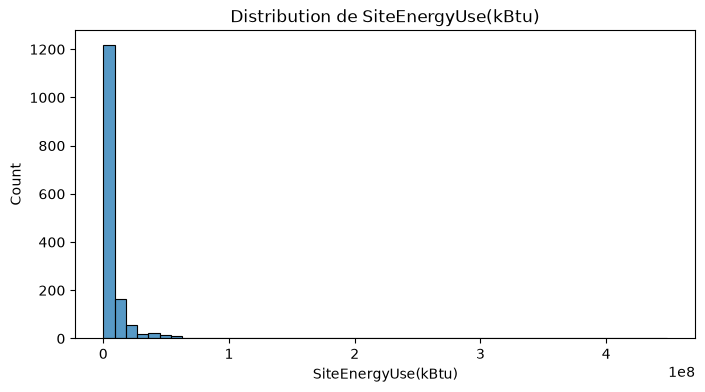

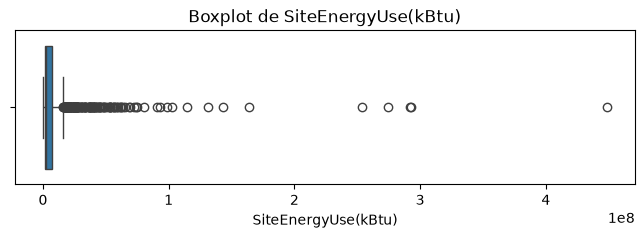

Skewness : 10.749389782229546


In [20]:
# Target pour le reste du projet = SiteEnergyUse
target = "SiteEnergyUse(kBtu)"

# Statistiques descriptives de la target : ça donne l'ordre de grandeur
# (min, max, moyenne, médiane, quartiles...)
print(building_consumption[target].describe())

# Histogramme : pour voir la forme de la distribution
plt.figure(figsize=(8, 4))
sns.histplot(building_consumption[target], bins=50)
plt.title(f"Distribution de {target}")
plt.show()

# Boxplot : complémentaire de l'histogramme
plt.figure(figsize=(8, 2))
sns.boxplot(x=building_consumption[target])
plt.title(f"Boxplot de {target}")
plt.show()

# Skewness
print(f"Skewness : {building_consumption[target].skew()}")

Ces visualisations ne sont pas très parlantes, je passe en Log

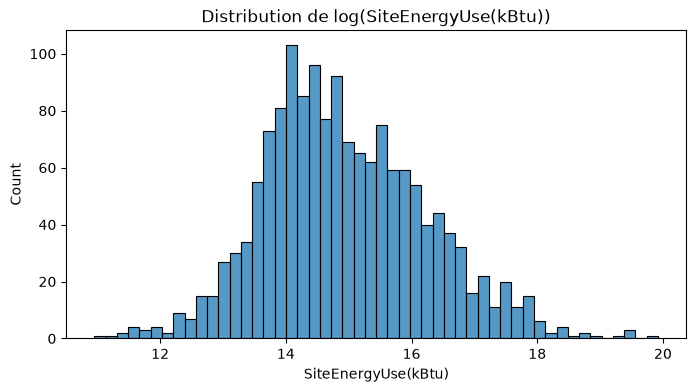

Skewness (log) : 0.35943406598607797


In [21]:
# On visualise la distribution sur une échelle log pour "rapprocher" les petites
# et les grandes valeurs et ainsi mieux voir la vraie forme de la distribution
plt.figure(figsize=(8, 4))
sns.histplot(np.log(building_consumption[target]), bins=50)
plt.title(f"Distribution de log({target})")
plt.show()

# On regarde aussi le skewness sur cette échelle log, pour comparer
print(f"Skewness (log) : {np.log(building_consumption[target]).skew()}")

Beaucoup plus parlant

## 1.8 Statistiques descriptives après nettoyage

In [22]:
"""Statistiques descriptives APRÈS nettoyage (à comparer avec la 1.3)"""
# Mêmes colonnes qu'en 1.3 (on réutilise la liste) pour comparer avant / après sur la même base
# Choix des colonnes : les variables STRUCTURELLES numériques (utilisables par le modèle) + la cible
# Colonnes écartées volontairement :
# - consommations détaillées (électricité, gaz...) : ce sont des morceaux de la cible -> data leakage
# - Latitude / Longitude : des coordonnées, leur moyenne n'a pas de sens
# - ZipCode / CouncilDistrictCode : des codes de zones, pas des quantités
# - surfaces par usage (LargestPropertyUseTypeGFA...) : des sous-parties de la surface totale, redondantes ici
colonnes_cles = colonnes_cles_brutes

# .T = on "retourne" le tableau : une ligne par variable, plus lisible
stats = building_consumption[colonnes_cles].describe().T

# Ratio moyenne / médiane : si > 1, quelques très grandes valeurs tirent la moyenne vers le haut
# -> distribution asymétrique (comme vu pour la cible en 1.7)
stats["ratio_moyenne_mediane"] = (stats["mean"] / stats["50%"]).round(2)

stats.round(1)

,count,mean,std,min,25%,50%,75%,max,ratio_moyenne_mediane
PropertyGFATotal,1528.0,113620.7,195921.8,11285.0,28806.0,47977.5,104460.5,2200000.0,2.4
PropertyGFABuilding(s),1528.0,99597.2,172839.8,3636.0,27828.5,45853.0,94101.5,2200000.0,2.2
PropertyGFAParking,1528.0,14023.5,43978.3,0.0,0.0,0.0,0.0,512608.0,inf
NumberofFloors,1528.0,4.3,6.4,1.0,1.0,2.0,4.0,76.0,2.1
NumberofBuildings,1528.0,1.1,1.2,1.0,1.0,1.0,1.0,27.0,1.1
YearBuilt,1528.0,1961.6,32.8,1900.0,1930.0,1965.5,1988.0,2015.0,1.0
SiteEnergyUse(kBtu),1528.0,8204976.4,22318095.2,57133.2,1243815.4,2687720.4,7243102.8,448385312.0,3.0


**Lecture des statistiques après nettoyage (1 528 bâtiments, contre 1 668)**

**Ce que le nettoyage a corrigé :**
- Plus aucun bâtiment à **0 étage**, **0 bâtiment** ou **0 kBtu** : la consommation minimale est désormais de 57 133 kBtu
- Les extrêmes les plus aberrants ont disparu notamment avec le retrait des bâtiments à 0 étage, dont le campus de l'université de Washington saisi comme un seul relevé: la surface max passe de **9,3 M à 2,2 M sqft**, la consommation max de **874 M à 448 M kBtu**.

**Ce qui reste vrai :**
- **Distributions asymétriques** : pour les surfaces, les étages et la cible, la moyenne est 2 à 3 fois plus élevée que la médiane. Quelques très grands bâtiments tirent la moyenne vers le haut : je raisonne donc en **médianes**, et en **échelle log** pour visualiser et modéliser.
- **`YearBuilt` est la seule variable symétrique** (moyenne ≈ médiane ≈ 1962).
- **`PropertyGFAParking`** : au moins 75 % des bâtiments n'ont pas de parking (médiane et 3e quartile à 0). Le ratio « inf » vient d'une division par une médiane nulle.
- **`NumberofBuildings`** : presque toujours égal à 1. Le max de 27 correspond à un campus.

**Nombre d'étages désormais plausible** : le maximum est de 76 étages (Columbia Center, plus haut bâtiment de Seattle), après correction de l'église à 99 étages en 1.6.

## 1.9 Liens entre les features et la cible (corrélations, boxplots par type)

**Mesurer le lien entre deux variables : Pearson ou Spearman ?**

Une corrélation est un nombre entre −1 et 1 : proche de 1, les deux variables montent ensemble ; proche de −1, l'une monte quand l'autre descend ; proche de 0, pas de lien régulier.

- **Pearson** mesure si les points s'alignent sur une **ligne droite**. Il est très sensible aux valeurs extrêmes : quelques bâtiments géants peuvent à eux seuls créer ou masquer un lien.
- **Spearman** travaille sur les **classements** (« le 10e plus grand bâtiment est-il aussi le 10e plus gros consommateur ? »). Il détecte toute relation qui monte ou descend régulièrement, même courbée, et résiste aux valeurs extrêmes.

Nos distributions étant très asymétriques, je compare d'abord les deux méthodes sur les principales variables, avant de choisir celle utilisée pour la suite de l'exploration.

**Nuages de points et comparaison Pearson / Spearman**

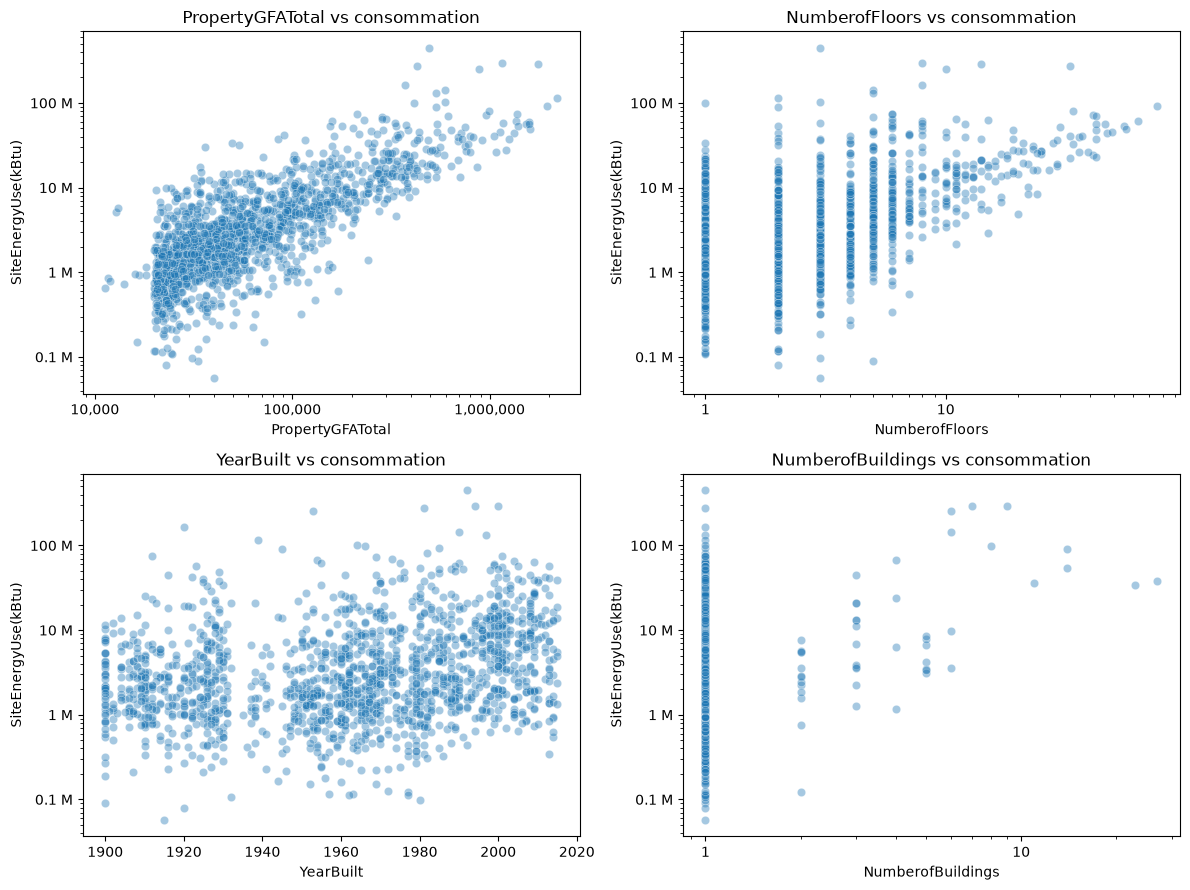

,pearson,spearman
PropertyGFATotal,0.59,0.74
NumberofFloors,0.35,0.47
YearBuilt,0.14,0.28
NumberofBuildings,0.25,0.12


In [23]:
"""Lien entre chaque variable structurelle et la consommation + comparaison Pearson / Spearman"""
from matplotlib.ticker import FuncFormatter  # pour des libellés lisibles au lieu de 10^6

variables = ["PropertyGFATotal", "NumberofFloors", "YearBuilt", "NumberofBuildings"]

# Grille de 2x2 graphiques
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

for ax, var in zip(axes.flatten(), variables):
    sns.scatterplot(data=building_consumption, x=var, y=target, ax=ax, alpha=0.4)
    ax.set_yscale("log")  # échelle log : les axes gardent les vraies unités, mais les géants n'écrasent plus tout
    ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v/1e6:g} M"))  # 1000000 -> "1 M"
    if var != "YearBuilt":  # une année ne se met pas en log
        ax.set_xscale("log")
        ax.xaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:,.0f}"))  # 100000 -> "100,000"
    ax.set_title(f"{var} vs consommation")

plt.tight_layout()
plt.show()

# Les deux corrélations côte à côte (définitions dans le markdown au-dessus)
correlations = pd.DataFrame({
    "pearson": building_consumption[variables].corrwith(building_consumption[target], method="pearson"),
    "spearman": building_consumption[variables].corrwith(building_consumption[target], method="spearman"),
}).round(2)
correlations

**Lecture des nuages de points et des corrélations**

- **La surface est le lien le plus fort** (Spearman 0,74) : plus un bâtiment est grand, plus il consomme. En échelle log, le nuage forme une bande régulière.
- **Spearman > Pearson pour la surface, les étages et l'année** : la relation existe et va dans un sens régulier, mais elle n'est pas en ligne droite, et les très gros bâtiments perturbent Pearson.
- **`YearBuilt` a un lien faible** (0,14 / 0,28) : l'âge seul explique peu la consommation, et son effet n'est pas linéaire

**Choix :** Spearman reflète mieux les liens sur nos données asymétriques. Je l'utilise pour la suite de l'exploration.

**Corrélations de toutes les colonnes numériques avec la cible (alerte data leakage)**

In [24]:
"""Corrélations (Spearman) de chaque colonne numérique avec la cible : alerte data leakage"""
# On inclut volontairement TOUTES les colonnes numériques, y compris les consommations détaillées
colonnes_numeriques = building_consumption.select_dtypes(include="number")

# Une corrélation très proche de 1 = la colonne "contient" quasiment la réponse -> suspicion de fuite
correlations_target = colonnes_numeriques.corr(method="spearman")[target].sort_values(ascending=False)
print(correlations_target.round(2))

SiteEnergyUse(kBtu)                1.00
SiteEnergyUseWN(kBtu)              0.98
Electricity(kWh)                   0.93
Electricity(kBtu)                  0.93
TotalGHGEmissions                  0.86
PropertyGFATotal                   0.74
SourceEUI(kBtu/sf)                 0.73
PropertyGFABuilding(s)             0.72
SiteEUI(kBtu/sf)                   0.72
SourceEUIWN(kBtu/sf)               0.72
LargestPropertyUseTypeGFA          0.70
SiteEUIWN(kBtu/sf)                 0.69
NumberofFloors                     0.47
GHGEmissionsIntensity              0.44
NaturalGas(therms)                 0.43
NaturalGas(kBtu)                   0.43
PropertyGFAParking                 0.37
SecondLargestPropertyUseTypeGFA    0.34
YearBuilt                          0.28
CouncilDistrictCode                0.23
SteamUse(kBtu)                     0.23
ThirdLargestPropertyUseTypeGFA     0.21
NumberofBuildings                  0.12
Latitude                           0.06
Longitude                         -0.06


**Lecture des corrélations avec la cible**

- **Des colonnes quasi identiques à la cible** : `SiteEnergyUseWN` (0,98), `Electricity` (0,93), `TotalGHGEmissions` (0,86). Ce ne sont pas des caractéristiques du bâtiment mais des **morceaux ou des transformations de la consommation** (version corrigée de la météo, part électrique, émissions calculées à partir de l'énergie). Les utiliser reviendrait à donner la réponse au modèle : **data leakage**
- **Les intensités (`SiteEUI`, `SourceEUI`, ≈ 0,72)** sont aussi de la fuite : elles valent consommation ÷ surface.
- **La corrélation ne suffit pas à repérer la fuite** :
  - la meilleure variable structurelle, `PropertyGFATotal` (0,74), est au même niveau que des colonnes de fuite. Un seuil de corrélation ne permet donc pas de les séparer.
  - à l'inverse, `ENERGYSTARScore` n'est que faiblement corrélé (−0,14), mais il est calculé à partir de la consommation réelle : c'est aussi de la fuite.
- **`ZipCode` (−0,17) et `CouncilDistrictCode` (0,23)** : ces valeurs n'ont pas de sens, car ce sont des **codes de zones** et non des quantités (le code 98104 n'est pas « plus grand » que 98101). Ils seront traités comme des catégories.
- **`Latitude` / `Longitude` (≈ 0)** : pas de lien régulier du type « plus au nord = plus de consommation ». La localisation peut toutefois jouer par zones, ce que le modèle pourra capter.

**Heatmap des liens entre variables structurelles**

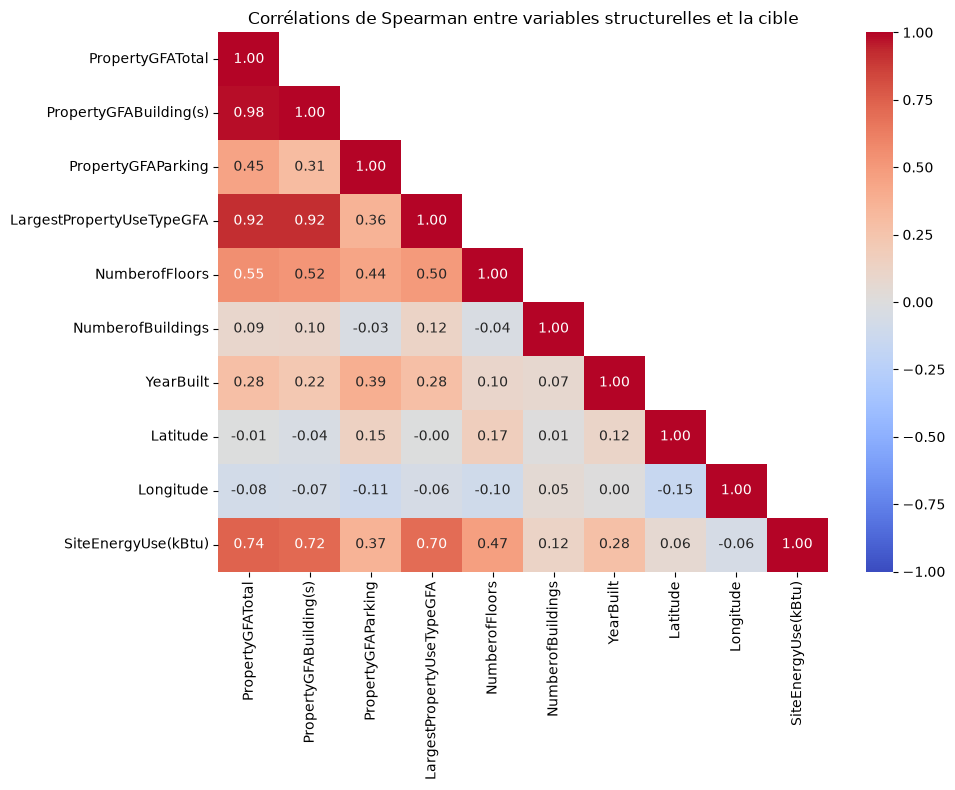

In [25]:
"""Heatmap annotée des variables structurelles (Spearman)"""
# On se limite aux variables structurelles (connues sans mesurer la consommation) + la cible
# -> une matrice lisible, où on peut afficher les valeurs dans les cases
variables_structurelles = [
    "PropertyGFATotal", "PropertyGFABuilding(s)", "PropertyGFAParking",
    "LargestPropertyUseTypeGFA", "NumberofFloors", "NumberofBuildings",
    "YearBuilt", "Latitude", "Longitude", target,
]

# Spearman : choisi plus haut, plus fiable sur nos distributions asymétriques
corr_spearman = building_consumption[variables_structurelles].corr(method="spearman")

# Masque du triangle supérieur : la matrice est symétrique (A-B = B-A), on n'affiche chaque paire qu'une fois
masque = np.triu(np.ones_like(corr_spearman, dtype=bool), k=1)

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_spearman,
    mask=masque,
    annot=True, fmt=".2f",   # affiche la valeur dans chaque case, 2 décimales
    cmap="coolwarm", center=0, vmin=-1, vmax=1,  # échelle fixe de -1 à 1 : les couleurs sont comparables
)
plt.title("Corrélations de Spearman entre variables structurelles et la cible")
plt.tight_layout()
plt.show()

**Lecture de la heatmap**

- **Les surfaces sont redondantes entre elles** : `PropertyGFATotal` / `PropertyGFABuilding(s)` = 0,98 et `LargestPropertyUseTypeGFA` ≈ 0,92. Elles portent presque la même information, ce qui sera à traiter avant la modélisation (cf. 3.2).
- **Le nombre d'étages n'est que moyennement lié à la surface (0,55)** : un grand bâtiment peut être bas et étendu (entrepôt) ou haut et compact (tour de bureaux). C'est donc une information complémentaire.
- **Les bâtiments récents sont un peu plus grands** (`YearBuilt` / surface = 0,28) **et ont plus souvent un parking** (0,39). Une partie du lien entre l'année et la consommation (0,28) passe donc probablement par la taille, pas par l'âge lui-même.
- **`NumberofBuildings`, `Latitude` et `Longitude` sont quasi indépendantes** de toutes les autres variables.

**Comparaison de la cible selon le type de bâtiment (`BuildingType`)**

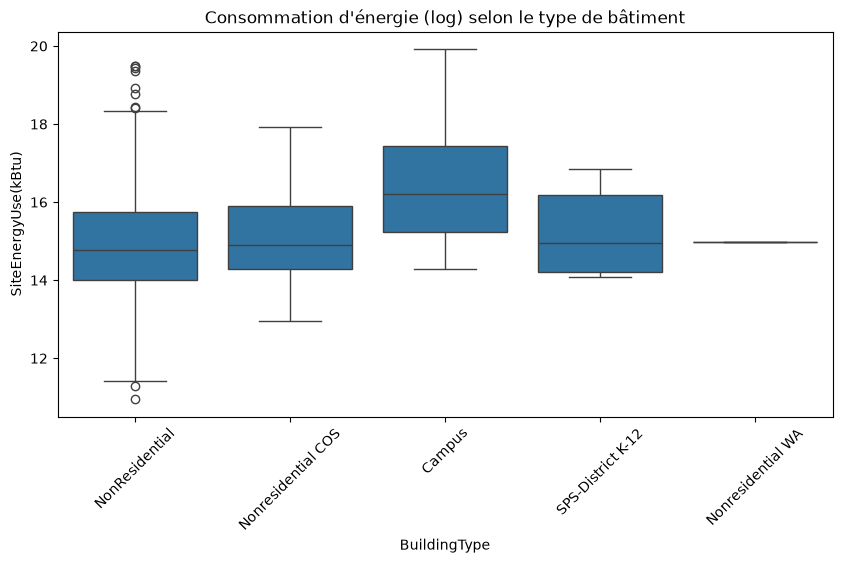

In [26]:
# Comparaison de la target selon le type de bâtiment (variable catégorielle)
# On utilise un boxplot plutôt qu'une corrélation, car BuildingType n'est pas numérique
plt.figure(figsize=(10, 5))
sns.boxplot(
    data=building_consumption,
    x="BuildingType",
    y=np.log(building_consumption[target]),  # on garde le log, plus lisible
)
plt.xticks(rotation=45)
plt.title("Consommation d'énergie (log) selon le type de bâtiment")
plt.show()

Pas très informatif, les `BuildingType` ne sont pas assez variés.
**Je fais la même chose avec `PrimaryPropertyType`**

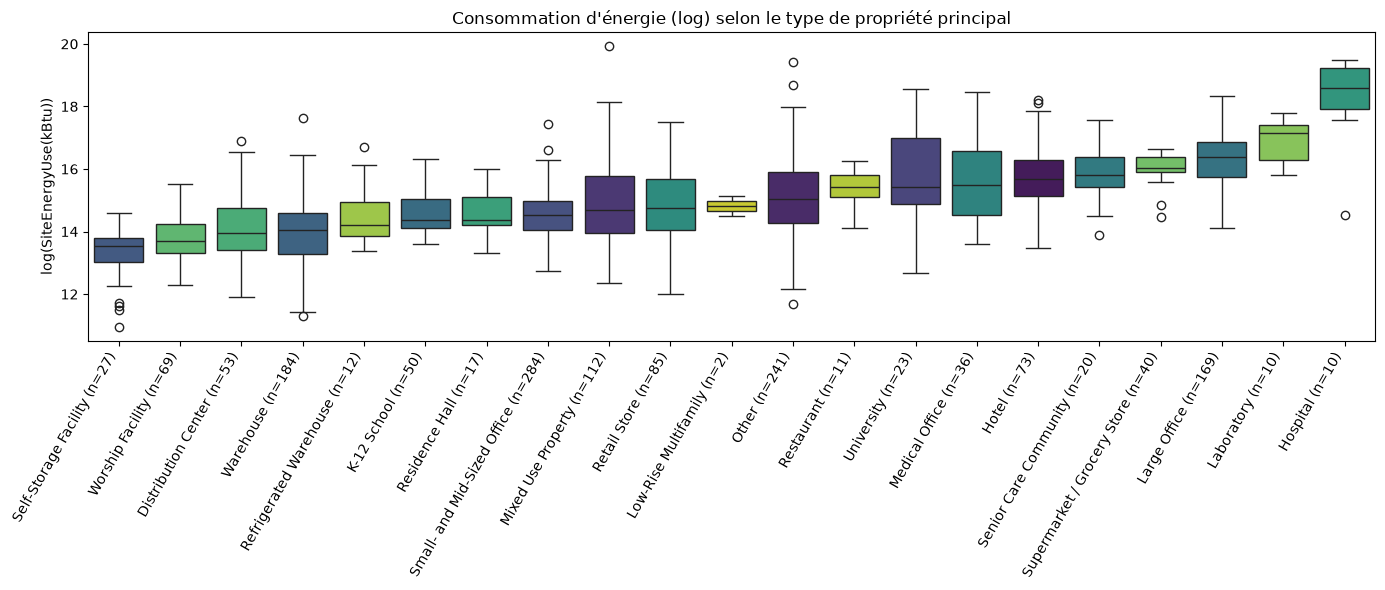

In [27]:
# PrimaryPropertyType est bien plus granulaire que BuildingType, donc plus informatif
# On trie les catégories par médiane de consommation pour rendre le graphique lisible
ordre_categories = (
    building_consumption.groupby("PrimaryPropertyType")[target]
    .median()
    .sort_values(ascending=True)
    .index
)

# Nombre de bâtiments par catégorie, remis dans le MÊME ordre que les boîtes du graphique
# (reindex = "réordonne selon cette liste")
effectifs = building_consumption["PrimaryPropertyType"].value_counts().reindex(ordre_categories)

plt.figure(figsize=(14, 6))
ax = sns.boxplot(          # on stocke le graphique dans "ax" pour pouvoir le modifier ensuite
    data=building_consumption,
    x="PrimaryPropertyType",
    y=np.log(building_consumption[target]),
    hue="PrimaryPropertyType",
    palette="viridis",
    order=ordre_categories,  # applique le tri qu'on vient de calculer
    legend=False,            # la couleur sert juste à distinguer les boîtes, pas besoin de légende
)

# On remplace les libellés de l'axe X par "Nom de la catégorie (n=effectif)"
# Rappel : une boîte construite sur 2-3 bâtiments est peu fiable, le "n" permet de le voir d'un coup d'oeil
nouveaux_labels = [f"{categorie} (n={n})" for categorie, n in effectifs.items()]
ax.set_xticks(range(len(ordre_categories)))   # une graduation par boîte
ax.set_xticklabels(nouveaux_labels, rotation=60, ha="right")

ax.set_xlabel("")  # le nom de l'axe est inutile, les libellés parlent d'eux-mêmes
ax.set_ylabel(f"log({target})")
plt.title("Consommation d'énergie (log) selon le type de propriété principal")
plt.tight_layout()
plt.show()

On constate que le `PrimaryPropertyType` est plus parlant et que les grands bureaux, les laboratoires et les hôpitaux sont dans le haut des consommations

**Bâtiments mono-usage vs multi-usages**

Multi-usages    0.55
Mono-usage      0.45
Name: proportion, dtype: float64
              PropertyGFATotal  SiteEnergyUse(kBtu)
Mono-usage             41255.0           1958519.25
Multi-usages           56942.0           3603160.50
Mono-usage      49.75
Multi-usages    56.75
Name: SiteEUI(kBtu/sf), dtype: float64


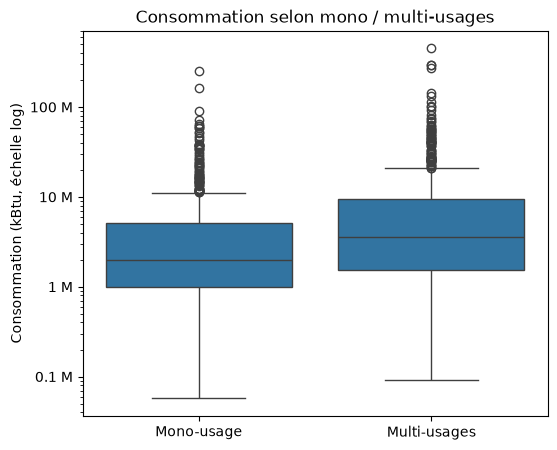

In [28]:
"""Comparaison des bâtiments mono-usage et multi-usages"""
from matplotlib.ticker import FuncFormatter  # sert à rendre l'axe Y lisible ("1 M" au lieu de 10^6)

# Série temporaire (pas ajoutée au dataframe) : un bâtiment est "multi" s'il a un 2e usage déclaré
type_usage = np.where(building_consumption["SecondLargestPropertyUseType"] == "None", "Mono-usage", "Multi-usages")

# Combien de bâtiments dans chaque groupe ?
print(pd.Series(type_usage).value_counts(normalize=True).round(2))  # en proportion

# Médianes par groupe : surface et consommation
# (médiane et pas moyenne, car les distributions sont asymétriques -> cf. 1.8)
print(building_consumption.groupby(type_usage)[["PropertyGFATotal", target]].median())

# Consommation PAR SURFACE (kBtu/sqft) : neutralise l'effet taille
# -> si les multi-usages consomment aussi plus par sqft, l'écart ne vient pas que de leur taille
print(building_consumption.groupby(type_usage)["SiteEUI(kBtu/sf)"].median())

# Boxplot de la consommation (log) par groupe
plt.figure(figsize=(6, 5))
sns.boxplot(x=type_usage, y=building_consumption[target])
plt.yscale("log")
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda valeur, _: f"{valeur/1e6:g} M"))
plt.title("Consommation selon mono / multi-usages")
plt.ylabel("Consommation (kBtu, échelle log)")
plt.show()

**Mono-usage vs multi-usages**

- **55 % des bâtiments sont multi-usages.**
- En médiane, ils sont **38 % plus grands** (56 942 vs 41 255 sqft) et consomment **84 % de plus** (3,6 M vs 2,0 M kBtu).
- Pour séparer l'effet de la taille, je compare la **consommation par sqft** (`SiteEUI`) : les multi-usages consomment **14 % de plus par sqft** (56,8 vs 49,8 kBtu/sqft).

**Conclusion :** l'écart de consommation vient **surtout de la taille** des bâtiments multi-usages, mais le mélange d'usages ajoute un effet propre, plus modeste.
Cela justifie de donner au modèle l'information sur les usages secondaires.

*Note : `SiteEUI` est utilisée ici uniquement pour l'exploration. Elle est calculée à partir de la consommation réelle, donc elle sera retirée avant la modélisation pour éviter le data leakage

**Vue croisée des principales variables (pairplot)**

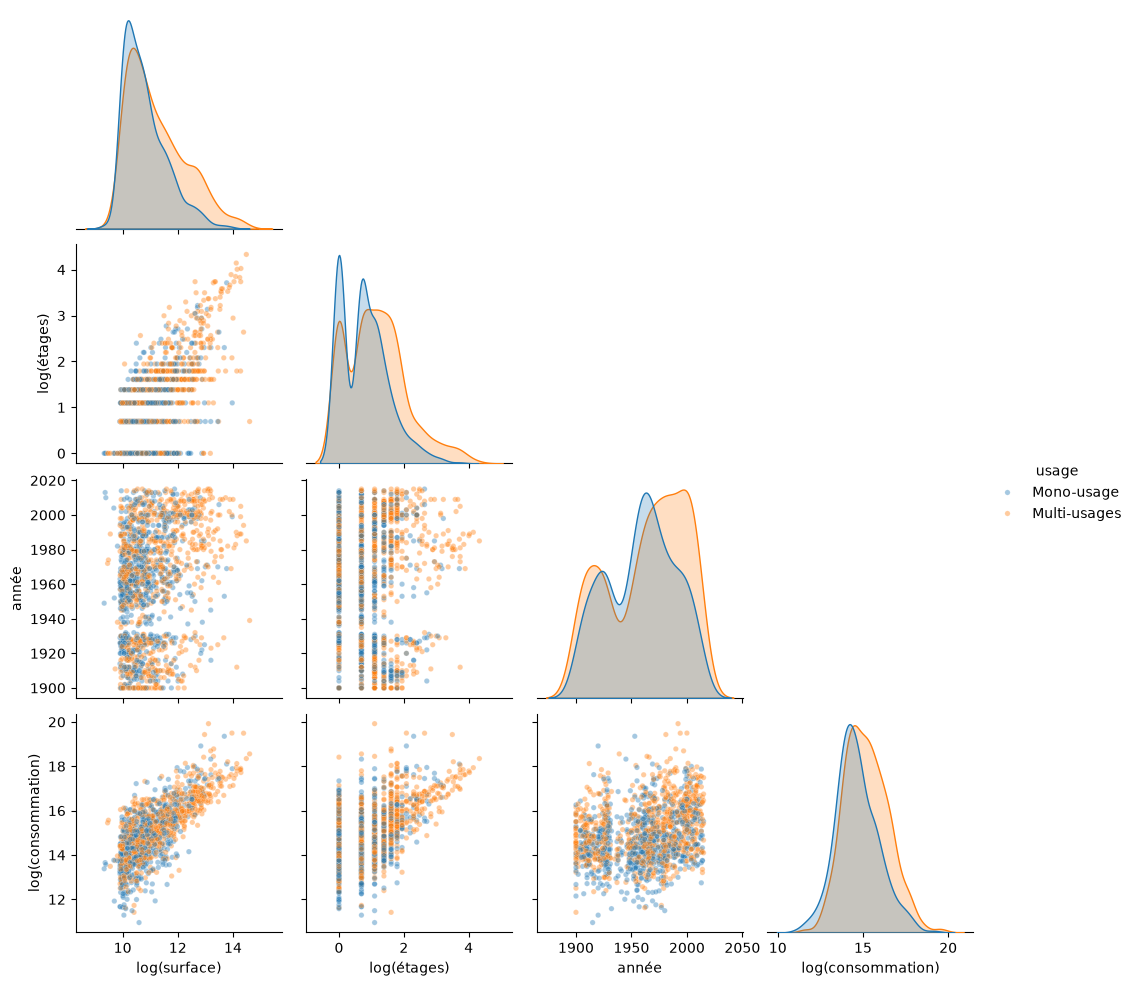

In [29]:
"""Pairplot : vue croisée des principales variables (mono vs multi-usages)"""
# Tableau temporaire, avec le log des variables asymétriques (cf. 1.8) pour que les nuages soient lisibles
# Parking exclu : 80 % de zéros, et log(0) est impossible
donnees_pairplot = pd.DataFrame({
    "log(surface)": np.log(building_consumption["PropertyGFATotal"]),
    "log(étages)": np.log(building_consumption["NumberofFloors"]),
    "année": building_consumption["YearBuilt"],
    "log(consommation)": np.log(building_consumption[target]),
    "usage": type_usage,   # défini dans la cellule mono/multi juste au-dessus
})

# corner=True : n'affiche que le triangle inférieur (le reste serait en double)
# hue="usage" : une couleur par groupe mono / multi
sns.pairplot(donnees_pairplot, hue="usage", corner=True, plot_kws={"alpha": 0.4, "s": 15})
plt.show()

**Lecture du pairplot**

- **log(surface) vs log(consommation)** : une bande nette et quasi rectiligne. En échelle log, le lien taille/consommation est presque linéaire, ce qui conforte le passage de la cible en log pour la modélisation.
- **Plus aucun point isolé en nombre d'étages** : le bâtiment de 99 étages n'apparaît plus. Le plus haut est désormais à 76 étages, cohérent avec sa surface.
- **Distribution des années en deux vagues** (1900-1930 et 1950-2010), avec un creux autour de 1930-1945 qui correspond à la crise et à la guerre. Les multi-usages sont surreprésentés parmi les constructions récentes.
- **Sur la diagonale, les multi-usages (orange) sont décalés vers la droite** en surface, en étages et en consommation, ce qui confirme l'analyse mono/multi.

## 1.10 Récap du nombre de lignes par étapes

| Étape | Bâtiments | Retirés | Corrigés |
|---|---|---|---|
| Relevés initiaux | 3 376 | – | – |
| Non résidentiels | 1 668 | 1 708 | – |
| Usage principal renseigné | 1 662 | 6 | – |
| Données conformes | 1 544 | 118 | – |
| Au moins 1 étage | 1 528 | 16 | – |
| Imputation : église à 99 étages (→ 2 étages) | 1 528 | – | 1 |
| Imputation : 0 bâtiment (→ 1 bâtiment) | 1 528 | – | 51 |
| Surface incohérente (2.3) | 1 527 | 1 | – |

# Modélisation

### Import des modules

In [30]:
#Selection
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    cross_validate,
)
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.inspection import permutation_importance

#Preprocess
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler

#Modèles
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor


# 2. Feature Engineering

A réaliser : Enrichir le jeu de données actuel avec de nouvelles features issues de celles existantes.

En règle générale : On utilise la méthode .apply() de Pandas pour créer une nouvelle colonne à partir d'une colonne existante. N'hésitez pas à regarder les exemples dans les chapitres de cours donnés en ressource -> J'ai préféré faire en vectorisé, je trouve ça plus lisible

In [31]:
# CODE FEATURE ENGINEERING

## 2.1 Temporalité : analyse par année, puis par décennie, et création de decennie_construction

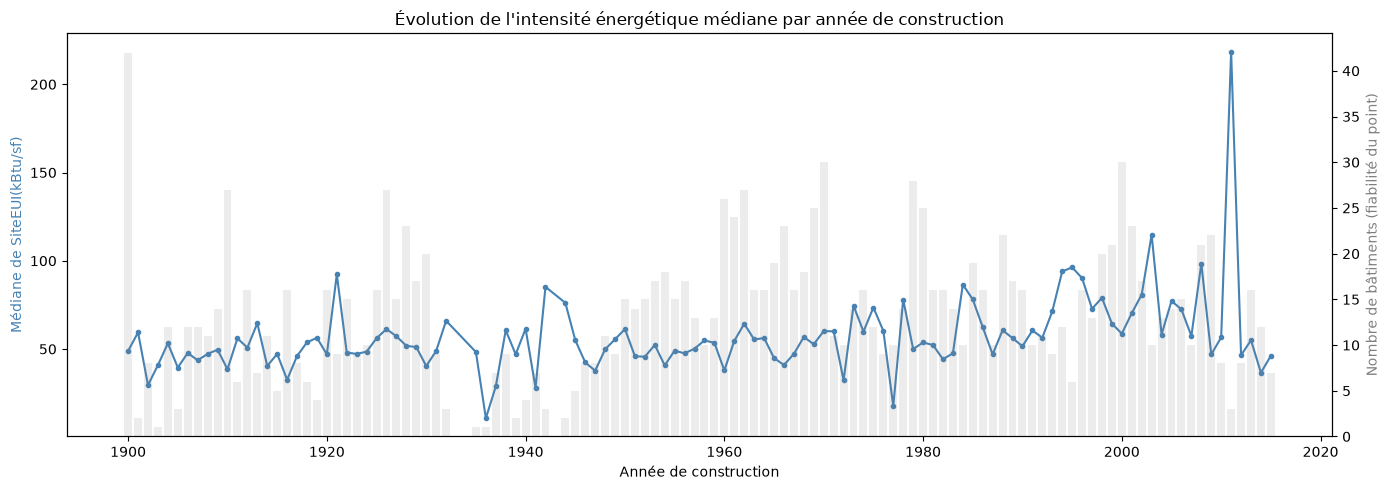

In [32]:
# Afin de pouvoir avancer dans le feature engineering
# Je vérifie si l'on peut observer une Année avec une cassure en terme d'efficience
# On utilise SiteEUI plutôt que la target brute, car je cherche ici un effet, indépendant de la taille du batiment
metrique_efficience = "SiteEUI(kBtu/sf)"

conso_par_annee = building_consumption.groupby("YearBuilt")[metrique_efficience].median()
nb_batiments_par_annee = building_consumption.groupby("YearBuilt")[metrique_efficience].count()

fig, ax1 = plt.subplots(figsize=(14, 5))
ax1.plot(conso_par_annee.index, conso_par_annee.values, color="steelblue", marker="o", markersize=3)
ax1.set_xlabel("Année de construction")
ax1.set_ylabel(f"Médiane de {metrique_efficience}", color="steelblue")
ax1.set_title("Évolution de l'intensité énergétique médiane par année de construction")

ax2 = ax1.twinx()
ax2.bar(nb_batiments_par_annee.index, nb_batiments_par_annee.values, alpha=0.15, color="gray")
ax2.set_ylabel("Nombre de bâtiments (fiabilité du point)", color="gray")

plt.tight_layout()
plt.show()

Pas vraiment d'année atypique, à part 2010 mais seulement 3 batiments contruits donc médiane biaisé  
Je teste en dessous en faisant un bucketing par décénnie de construction

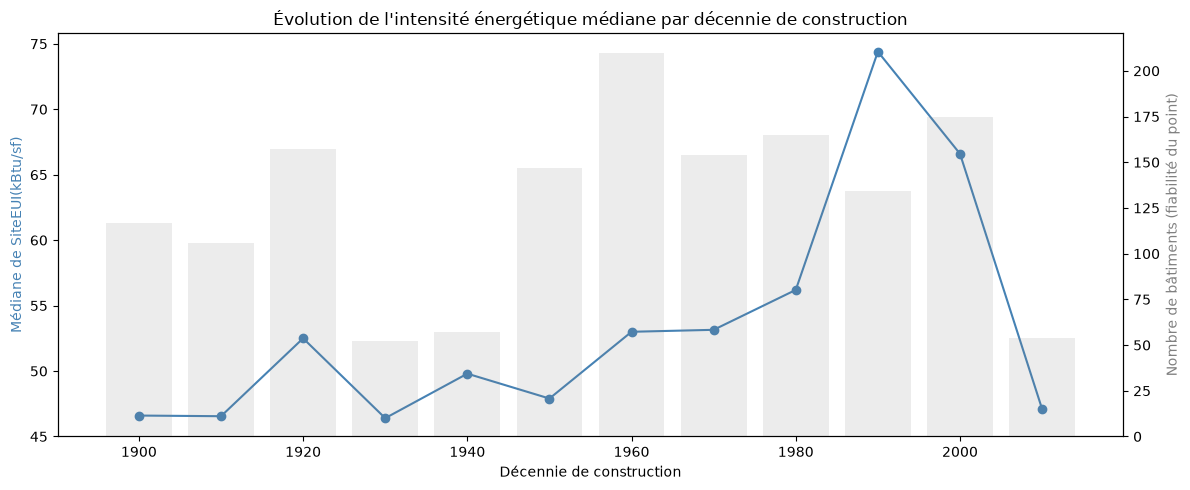

In [33]:
# Même analyse, mais regroupée par décennie plutôt que par année exacte
building_consumption["decennie_construction"] = (building_consumption["YearBuilt"] // 10) * 10

conso_par_decennie = building_consumption.groupby("decennie_construction")[metrique_efficience].median()
nb_batiments_par_decennie = building_consumption.groupby("decennie_construction")[metrique_efficience].count()

fig, ax1 = plt.subplots(figsize=(12, 5))
ax1.plot(conso_par_decennie.index, conso_par_decennie.values, color="steelblue", marker="o")
ax1.set_xlabel("Décennie de construction")
ax1.set_ylabel(f"Médiane de {metrique_efficience}", color="steelblue")
ax1.set_title("Évolution de l'intensité énergétique médiane par décennie de construction")

ax2 = ax1.twinx()
ax2.bar(nb_batiments_par_decennie.index, nb_batiments_par_decennie.values, width=8, alpha=0.15, color="gray")
ax2.set_ylabel("Nombre de bâtiments (fiabilité du point)", color="gray")

plt.tight_layout()
plt.show()

On constate plusieurs tendances en fonction des décennies, augmentation ou diminution de l'efficience par sqft

In [34]:
"""Feature Engineering - Temporalité"""

# On transforme l'année de construction en décennie (catégorielle)
building_consumption["decennie_construction"] = (building_consumption["YearBuilt"] // 10) * 10

# On vérifie que chaque décennie a un volume de bâtiments suffisant pour être exploitable
print(building_consumption["decennie_construction"].value_counts().sort_index())

decennie_construction
1900    117
1910    106
1920    157
1930     52
1940     57
1950    147
1960    210
1970    154
1980    165
1990    134
2000    175
2010     54
Name: count, dtype: int64


## 2.2 Sources d'énergie : vérifications, puis indicateurs 0/1

In [35]:
# Vérification préalable avant de créer les indicateurs de source d'énergie :
colonnes_energie = ["Electricity(kWh)", "NaturalGas(therms)", "SteamUse(kBtu)"]

for col in colonnes_energie:
    print(f"--- {col} ---")
    print(f"Nb de NaN : {building_consumption[col].isnull().sum()}")
    print(f"Nb de valeurs == 0 : {(building_consumption[col] == 0).sum()}")
    print(building_consumption[col].describe())
    print()

--- Electricity(kWh) ---
Nb de NaN : 0
Nb de valeurs == 0 : 2
count    1.528000e+03
mean     1.657026e+06
std      4.025887e+06
min     -3.382680e+04
25%      2.129975e+05
50%      4.966785e+05
75%      1.504899e+06
max      8.046087e+07
Name: Electricity(kWh), dtype: float64

--- NaturalGas(therms) ---
Nb de NaN : 0
Nb de valeurs == 0 : 438
count    1.528000e+03
mean     2.017102e+04
std      9.748393e+04
min      0.000000e+00
25%      0.000000e+00
50%      4.803805e+03
75%      1.524242e+04
max      2.979090e+06
Name: NaturalGas(therms), dtype: float64

--- SteamUse(kBtu) ---
Nb de NaN : 0
Nb de valeurs == 0 : 1418
count    1.528000e+03
mean     4.889622e+05
std      5.320966e+06
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      1.349435e+08
Name: SteamUse(kBtu), dtype: float64



Pas de NaN  
Attention sur le min négatif sur `Electricity(kWh)`, peut indiquer un bâtiment avec des panneaux solaires

In [36]:
"""Feature Engineering - Type d'energie utilisée par le batiment"""

# Indicateurs binaires de présence de chaque source d'énergie
# On utilise "!= 0" plutôt que "> 0" pour bien capturer les cas de bâtiments
# producteurs (ex: Bullitt Center, qui a un solde électrique négatif)
building_consumption["Electricity_Use"] = (building_consumption["Electricity(kWh)"] != 0).astype(int)
building_consumption["Gas_Use"] = (building_consumption["NaturalGas(therms)"] != 0).astype(int)
building_consumption["Steam_Use"] = (building_consumption["SteamUse(kBtu)"] != 0).astype(int)

# Variables binaires : effectif (somme des 1) ET proportion (moyenne des 0/1)
resume_energie = pd.DataFrame({
    "nb bâtiments": building_consumption[["Electricity_Use", "Gas_Use", "Steam_Use"]].sum(),
    "proportion": building_consumption[["Electricity_Use", "Gas_Use", "Steam_Use"]].mean().round(2),
})
resume_energie

,nb bâtiments,proportion
Electricity_Use,1526,1.00
Gas_Use,1090,0.71
Steam_Use,110,0.07


**Lecture des indicateurs de sources d'énergie**

Sur des variables 0/1, la moyenne correspond à la **proportion** de bâtiments concernés :
- **Électricité : 1 526 bâtiments sur 1 528 (100 %)**. La colonne est quasi constante : elle ne permet pas de distinguer les bâtiments entre eux et n'apporte donc aucune information au modèle → **candidate à la suppression**.
- **Gaz : 71 % des bâtiments**. Indicateur bien réparti, potentiellement informatif.
- **Vapeur : 7 % des bâtiments** (110). Rare, mais un réseau de vapeur urbain caractérise certains bâtiments du centre-ville : à conserver.

## 2.3 Usages multiples : indicateurs 0/1 et proportions par usage

In [37]:
"""Feature Engineering - Usages multiples"""

# Indicateurs binaires : le bâtiment a-t-il un usage secondaire / tertiaire ?
building_consumption["Has_Second_Use"] = (building_consumption["SecondLargestPropertyUseType"] != "None").astype(int)
building_consumption["Has_Third_Use"] = (building_consumption["ThirdLargestPropertyUseType"] != "None").astype(int)

# Proportions : quelle part de la surface totale est occupée par ces usages secondaire/tertiaire ?
# (entre 0 et 1 : 0 = aucune surface dédiée à cet usage, 1 = 100% du bâtiment)
building_consumption["Prop_Second_Use"] = building_consumption["SecondLargestPropertyUseTypeGFA"] / building_consumption["PropertyGFATotal"]
building_consumption["Prop_Third_Use"] = building_consumption["ThirdLargestPropertyUseTypeGFA"] / building_consumption["PropertyGFATotal"]

# --- Contrôle des nouvelles colonnes ---
# Variables BINAIRES (0/1) : la moyenne = la PROPORTION de bâtiments à 1
# (écart-type et quartiles n'ont pas de sens sur du 0/1, on ne les affiche pas)
print("Part des bâtiments ayant un 2e / 3e usage :")
print(building_consumption[["Has_Second_Use", "Has_Third_Use"]].mean().round(2))
# Vérification croisée : on doit retrouver les 55 % de multi-usages vus en 1.9

# Variables CONTINUES (proportions de surface) : describe() a du sens ici,
# mais seulement sur les bâtiments concernés (sinon les nombreux 0 écrasent la distribution)
print("\nPart de la surface dédiée au 2e usage (bâtiments multi-usages uniquement) :")
print(building_consumption.loc[building_consumption["Has_Second_Use"] == 1, "Prop_Second_Use"].describe().round(2))

# Contrôle de cohérence : une proportion de surface ne peut pas dépasser 1 (100 % du bâtiment)
print(f"\nBâtiments avec Prop_Second_Use > 1 : {(building_consumption['Prop_Second_Use'] > 1).sum()}")

Part des bâtiments ayant un 2e / 3e usage :
Has_Second_Use    0.55
Has_Third_Use     0.23
dtype: float64

Part de la surface dédiée au 2e usage (bâtiments multi-usages uniquement) :
count    834.00
mean       0.24
std        0.17
min        0.00
25%        0.11
50%        0.23
75%        0.34
max        1.29
Name: Prop_Second_Use, dtype: float64

Bâtiments avec Prop_Second_Use > 1 : 2


In [38]:
"""Inspection des 2 bâtiments dont le 2e usage dépasserait 100 % de la surface totale"""
building_consumption.loc[
    building_consumption["Prop_Second_Use"] > 1,
    ["PropertyName", "PrimaryPropertyType", "PropertyGFATotal", "PropertyGFABuilding(s)",
     "PropertyGFAParking", "SecondLargestPropertyUseType", "SecondLargestPropertyUseTypeGFA"]
]

,PropertyName,PrimaryPropertyType,PropertyGFATotal,PropertyGFABuilding(s),PropertyGFAParking,SecondLargestPropertyUseType,SecondLargestPropertyUseTypeGFA
35,Plant 2 Site,Mixed Use Property,494835,494835,0,Laboratory,639931.0
3294,Audi Seattle UVA Bldg,Other,33648,33648,0,Automobile Dealership,39000.0


In [39]:
"""Traitement des 2 bâtiments dont le 2e usage dépasse 100 % de la surface totale"""
nb_avant = building_consumption.shape[0]

# Plant 2 Site : surface totale incohérente (plus petite que son seul laboratoire)
# + intensité énergétique aberrante -> surface non fiable et non corrigeable -> suppression
building_consumption = building_consumption[building_consumption["PropertyName"] != "Plant 2 Site"]

# Audi Seattle : léger débordement (16 %) -> on plafonne la proportion à 1 (100 % du bâtiment)
# clip(upper=1) : toute valeur au-dessus de 1 est ramenée à 1, les autres ne bougent pas
# (appliqué aussi au 3e usage par précaution)
building_consumption["Prop_Second_Use"] = building_consumption["Prop_Second_Use"].clip(upper=1)
building_consumption["Prop_Third_Use"] = building_consumption["Prop_Third_Use"].clip(upper=1)

print(f"Lignes supprimées : {nb_avant - building_consumption.shape[0]}")
print(f"Nombre de bâtiments : {building_consumption.shape[0]}")
print(f"Max Prop_Second_Use après correction : {building_consumption['Prop_Second_Use'].max()}")

Lignes supprimées : 1
Nombre de bâtiments : 1527
Max Prop_Second_Use après correction : 1.0


**Lecture des features d'usages multiples**

- **55 % des bâtiments ont un 2e usage** et 23 % un 3e. Sur des variables 0/1, la moyenne correspond à la proportion de bâtiments concernés. On retrouve bien les 55 % de multi-usages de la 1.9.
- **Chez les multi-usages, le 2e usage occupe en médiane 23 % de la surface** (la moitié d'entre eux entre 11 % et 34 %).
- **Incohérence détectée : 2 bâtiments ont un 2e usage plus grand que leur surface totale** (proportion > 1, impossible).
  - **Plant 2 Site** : surface totale (494 835 sqft) plus petite que son seul laboratoire (639 931 sqft). sa consommation par sqft (~900 kBtu) est 18 fois la médiane. Sa surface, variable principale du modèle, n'est pas fiable et pas corrigeable → **suppression**.
  - **Audi Seattle** : débordement de 16 %, sans autre anomalie → **proportion plafonnée à 100 %**.

## 2.4 Récapitulatif des features créées

8 features créées, dont 5 conservées : `Electricity_Use`, `Has_Second_Use` et `Has_Third_Use` ont été écartées en 3.1.  
Elles sont réparties en 3 familles d'informations :

| Famille | Feature | Type | Contenu |
|---|---|---|---|
| Temporalité | `decennie_construction` | Catégorielle | Décennie de construction (ex : 1990) |
| Sources d'énergie | `Electricity_Use` | Binaire (0/1) | Le bâtiment utilise de l'électricité (presque tous à 1) |
| | `Gas_Use` | Binaire (0/1) | Le bâtiment utilise du gaz |
| | `Steam_Use` | Binaire (0/1) | Le bâtiment utilise de la vapeur |
| Usages multiples | `Has_Second_Use` / `Has_Third_Use` | Binaire (0/1) | Le bâtiment a un 2e / 3e usage |
| | `Prop_Second_Use` / `Prop_Third_Use` | Numérique (0 à 1) | Part de la surface dédiée au 2e / 3e usage |

**Pourquoi ces choix :**
- **Décennie plutôt qu'année** : l'effet de l'âge sur l'intensité énergétique n'est pas linéaire (les bâtiments des années 1990-2000 sont les moins efficients). Regrouper par décennie donne des groupes assez grands pour être fiables.
- **Présence plutôt que quantité d'énergie** : les quantités consommées (kWh, therms) sont des morceaux de la cible, donc du *data leakage*. Savoir si un bâtiment est équipé au gaz est en revanche une information structurelle, connue sans mesurer la consommation.
- **Usages multiples** : un bâtiment mixte (bureaux + parking, par exemple) ne consomme pas comme un bâtiment mono-usage. Les proportions indiquent en plus quel poids a chaque usage.

> Pas de fuite de données : toutes ces features peuvent être calculées pour un bâtiment dont on ne connaît pas encore la consommation.

# 3. Préparation des features pour la modélisation

A réaliser :
* Si ce n'est pas déjà fait, supprimer toutes les colonnes peu pertinentes pour la modélisation.
* Tracer la distribution de la cible pour vous familiariser avec l'ordre de grandeur. En cas d'outliers, mettez en place une démarche pour les supprimer.
* Débarrassez-vous des features redondantes en utilisant une matrice de corrélation de Pearson. Pour cela, utiisez la méthode corr() de Pandas, couplé d'un graphique Heatmap de la librairie Seaborn
* Réalisez différents graphiques pour comprendre le lien entre vos features et la target (boxplots, scatterplots, pairplot si votre nombre de features numériques n'est pas très élevé).
*  Séparez votre jeu de données en un Pandas DataFrame X (ensemble de feautures) et Pandas Series y (votre target).
* Si vous avez des features catégorielles, il faut les encoder pour que votre modèle fonctionne. Les deux méthodes d'encodage à connaitre sont le OneHotEncoder et le LabelEncoder

In [40]:
# CODE PREPARATION DES FEATURES

## 3.1 Suppression des colonnes (leakage, constantes, identifiants, redondantes)

In [41]:
"""Suppression de Features"""

# --- Groupe 1 : Data leakage ---
colonnes_leakage = [
    "SiteEnergyUseWN(kBtu)",
    "Electricity(kWh)", "Electricity(kBtu)",
    "NaturalGas(therms)", "NaturalGas(kBtu)",
    "SteamUse(kBtu)",
    "TotalGHGEmissions", "GHGEmissionsIntensity",
    "SiteEUI(kBtu/sf)", "SiteEUIWN(kBtu/sf)",
    "SourceEUI(kBtu/sf)", "SourceEUIWN(kBtu/sf)",
    "ENERGYSTARScore",
]

# --- Groupe 2 : Colonnes devenues constantes après nos filtres ---
colonnes_constantes = ["ComplianceStatus", "DefaultData"]

# --- Groupe 3 : Identifiant peu exploitable ---
colonnes_identifiants = ["PropertyName"]

# --- Groupe 4 : Colonnes brutes redondantes avec des features déjà créées ---
# YearBuilt remplacée par decennie_construction car les variations n'étaient pas assez visibles sinon
# Second/ThirdLargestPropertyUseTypeGFA -> remplacées par Prop_Second_Use / Prop_Third_Use
colonnes_redondantes = [
    "YearBuilt",
    "SecondLargestPropertyUseTypeGFA",
    "ThirdLargestPropertyUseTypeGFA",
]

# --- Groupe 5 : Cardinalité trop élevée pour être exploitable (quasi 1 valeur par bâtiment) ---
# Son information est portée par Second/ThirdLargestPropertyUseType et Prop_Second_Use / Prop_Third_Use
colonnes_trop_eparses = ["ListOfAllPropertyUseTypes"]

# --- Groupe 6 : Features créées en partie 2 mais finalement sans apport ---
# Electricity_Use : quasi constante -> ne distingue aucun bâtiment
# Has_Second_Use / Has_Third_Use : doublons exacts de l'information "None" de Second/ThirdLargestPropertyUseType,
#   que le One-Hot encode déjà en colonne à part (ex : SecondLargestPropertyUseType_None)
colonnes_features_sans_apport = ["Electricity_Use", "Has_Second_Use", "Has_Third_Use"]

building_consumption = building_consumption.drop(
    columns=colonnes_leakage + colonnes_constantes + colonnes_identifiants + colonnes_redondantes + colonnes_trop_eparses + colonnes_features_sans_apport
)



# Contrôle : combien de colonnes te reste-t-il, et sont-elles cohérentes ?
print(f"Nombre de colonnes restantes : {building_consumption.shape[1]}")
building_consumption.info()

Nombre de colonnes restantes : 22
<class 'pandas.DataFrame'>
Index: 1527 entries, 0 to 3375
Data columns (total 22 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   BuildingType                  1527 non-null   str    
 1   PrimaryPropertyType           1527 non-null   str    
 2   ZipCode                       1514 non-null   float64
 3   CouncilDistrictCode           1527 non-null   int64  
 4   Neighborhood                  1527 non-null   str    
 5   Latitude                      1527 non-null   float64
 6   Longitude                     1527 non-null   float64
 7   NumberofBuildings             1527 non-null   float64
 8   NumberofFloors                1527 non-null   int64  
 9   PropertyGFATotal              1527 non-null   int64  
 10  PropertyGFAParking            1527 non-null   int64  
 11  PropertyGFABuilding(s)        1527 non-null   int64  
 12  LargestPropertyUseType        1527 non-null 

## 3.2 Corrélations et suppression des features redondantes

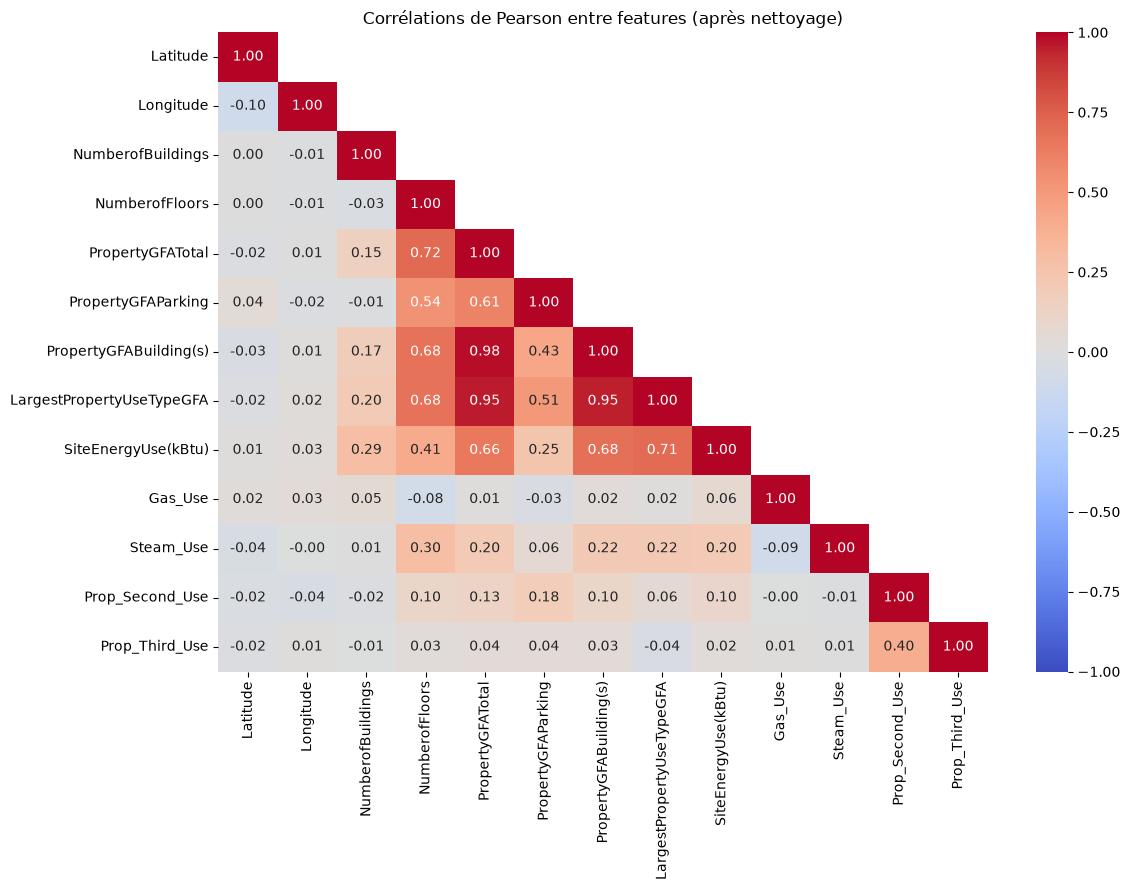

Paires de features redondantes (|corrélation| > 0,9) :
PropertyGFATotal        PropertyGFABuilding(s)       0.98
                        LargestPropertyUseTypeGFA    0.95
PropertyGFABuilding(s)  LargestPropertyUseTypeGFA    0.95
dtype: float64


In [42]:
"""Matrice de Pearson pour repérer les features redondantes entre elles"""
# On exclut les colonnes numériques qui sont en réalité des CODES (catégories) : une corrélation n'a pas de sens sur eux
# (elles seront converties en texte en 3.5)
colonnes_numeriques = building_consumption.select_dtypes(include="number").drop(
    columns=["ZipCode", "CouncilDistrictCode", "decennie_construction"]
)
corr_matrix = colonnes_numeriques.corr()   # Pearson par défaut

# Heatmap annotée, triangle inférieur seulement (la matrice est symétrique)
masque = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
plt.figure(figsize=(12, 9))
sns.heatmap(corr_matrix, mask=masque, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1)
plt.title("Corrélations de Pearson entre features (après nettoyage)")
plt.tight_layout()
plt.show()

# Liste des paires de features très corrélées entre elles (|r| > 0,9), sans la cible
# - .where(triangle) : garde chaque paire une seule fois
# - .stack() : transforme la matrice en liste de paires (feature A, feature B) -> valeur
corr_features = corr_matrix.drop(index=target, columns=target)
triangle = np.triu(np.ones_like(corr_features, dtype=bool), k=1)
paires_redondantes = corr_features.where(triangle).stack()
print("Paires de features redondantes (|corrélation| > 0,9) :")
print(paires_redondantes[paires_redondantes.abs() > 0.9].round(2))

In [43]:
"""Suppression des surfaces redondantes : on garde PropertyGFATotal"""
# PropertyGFABuilding(s) = PropertyGFATotal - PropertyGFAParking -> information déjà présente
# LargestPropertyUseTypeGFA = sous-partie de la surface totale -> quasi identique pour la majorité des bâtiments
colonnes_surfaces_redondantes = ["PropertyGFABuilding(s)", "LargestPropertyUseTypeGFA"]
building_consumption = building_consumption.drop(columns=colonnes_surfaces_redondantes)
print(f"Colonnes restantes : {building_consumption.shape[1]}")

Colonnes restantes : 20


### Analyse de la matrice de corrélation

**Objectif** : repérer les features qui portent la même information, pour n'en garder qu'une.

**Paires redondantes (|r| > 0,9) : uniquement les trois surfaces**
- `PropertyGFATotal` / `PropertyGFABuilding(s)` : 0,98
- `PropertyGFATotal` / `LargestPropertyUseTypeGFA` : 0,95
- `PropertyGFABuilding(s)` / `LargestPropertyUseTypeGFA` : 0,95

Cette redondance vient de leur construction même : la surface totale = surface bâtie + parking, et la surface de l'usage principal est une sous-partie de la surface totale.

**Décision : je garde `PropertyGFATotal` et je retire les deux autres.**
- C'est la mesure la plus complète, et la plus liée à la cible (Spearman 0,74, cf. 1.9).
- Aucune information n'est perdue : `PropertyGFAParking` étant conservée, la surface bâtie se déduit de la surface totale moins le parking.
- Garder les trois aurait donné trois fois la même information au modèle

Aucune autre paire de features ne dépasse 0,9 : les autres variables apportent chacune une information distincte.

## 3.3 Outliers de la cible : comparaison de 4 méthodes de détection

**Objectif** : repérer les bâtiments dont la consommation est si extrême qu'elle risque de perturber l'apprentissage.

**Méthodes comparées :**
- **IQR (écart interquartile)** : on mesure l'étendue des 50 % de bâtiments « du milieu » (entre le 1er quartile Q1 et le 3e quartile Q3). Est outlier tout bâtiment situé à plus de 1,5 fois cette étendue en dessous de Q1 ou au-dessus de Q3. Testée sur l'échelle **brute** et sur l'échelle **log**.
- **z-score** : on mesure à combien d'écarts-types de la moyenne se trouve chaque bâtiment. Est outlier tout bâtiment à plus de 3 écarts-types. Appliqué sur l'échelle log, car le z-score suppose une distribution à peu près symétrique, ce qui n'est vrai qu'en log (cf. 1.7).
- **Quantiles 1 % – 99 %** : on retire les 1 % de bâtiments les plus bas et les 1 % les plus hauts. Méthode la plus simple, mais elle retire **toujours** environ 2 % des bâtiments, qu'ils soient anormaux ou non.

In [44]:
"""Comparaison de 4 méthodes de détection des outliers de la cible"""
conso = building_consumption[target]
log_target = np.log(conso)   # log de la cible, utilisé par l'IQR log et le z-score

def bornes_iqr(serie):
    """Bornes IQR : [Q1 - 1,5 x IQR ; Q3 + 1,5 x IQR]"""
    q1, q3 = serie.quantile(0.25), serie.quantile(0.75)
    iqr = q3 - q1
    return q1 - 1.5 * iqr, q3 + 1.5 * iqr

# 1. IQR sur l'échelle brute
borne_basse_brut, borne_haute_brut = bornes_iqr(conso)
# 2. IQR sur l'échelle log
borne_basse_log, borne_haute_log = bornes_iqr(log_target)
# 3. z-score sur l'échelle log : moyenne + ou - 3 écarts-types
borne_basse_z = log_target.mean() - 3 * log_target.std()
borne_haute_z = log_target.mean() + 3 * log_target.std()
# 4. Quantiles 1 % et 99 %
borne_basse_q, borne_haute_q = conso.quantile(0.01), conso.quantile(0.99)

# Tableau récapitulatif : bornes ramenées en kBtu (np.exp annule le log) pour être comparables
comparaison_outliers = pd.DataFrame({
    "borne basse (kBtu)": [borne_basse_brut, np.exp(borne_basse_log), np.exp(borne_basse_z), borne_basse_q],
    "borne haute (kBtu)": [borne_haute_brut, np.exp(borne_haute_log), np.exp(borne_haute_z), borne_haute_q],
    "nb retirés": [
        ((conso < borne_basse_brut) | (conso > borne_haute_brut)).sum(),
        ((log_target < borne_basse_log) | (log_target > borne_haute_log)).sum(),
        ((log_target < borne_basse_z) | (log_target > borne_haute_z)).sum(),
        ((conso < borne_basse_q) | (conso > borne_haute_q)).sum(),
    ],
}, index=["IQR échelle brute", "IQR échelle log", "z-score échelle log (|z| > 3)", "Quantiles 1 % - 99 %"])

comparaison_outliers["% retirés"] = (comparaison_outliers["nb retirés"] / len(conso) * 100).round(1)
# Arrondi différent par colonne : bornes et nombres entiers, pourcentages à 1 décimale
comparaison_outliers.round({"borne basse (kBtu)": 0, "borne haute (kBtu)": 0, "% retirés": 1})

,borne basse (kBtu),borne haute (kBtu),nb retirés,% retirés
IQR échelle brute,-7741275.0,16218074.0,168,11.0
IQR échelle log,88632.0,101481029.0,11,0.7
z-score échelle log (|z| > 3),62914.0,149435960.0,6,0.4
Quantiles 1 % - 99 %,180655.0,71789548.0,32,2.1


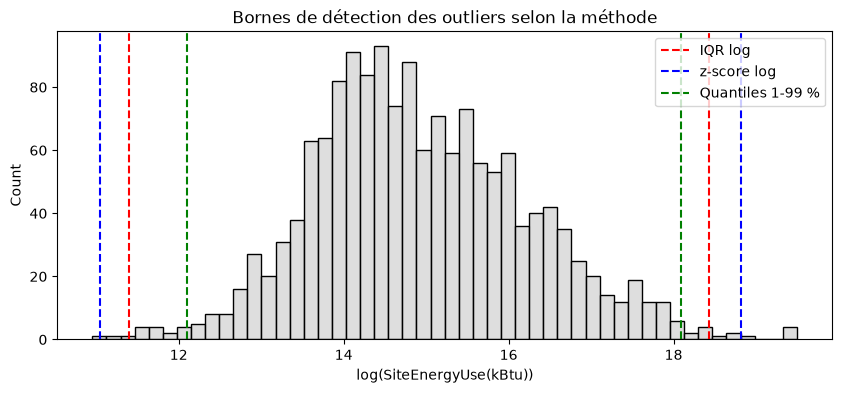

In [45]:
"""Où chaque méthode coupe-t-elle la distribution ?"""
# Assistance Claude
# IQR brut absent : sa borne basse est négative, impossible à placer en log (cf. tableau)
plt.figure(figsize=(10, 4))
sns.histplot(log_target, bins=50, color="lightgray")

# Une couleur par méthode, ligne verticale à chaque borne
for (bas, haut), couleur, nom in [
    ((borne_basse_log, borne_haute_log), "red", "IQR log"),
    ((borne_basse_z, borne_haute_z), "blue", "z-score log"),
    ((np.log(borne_basse_q), np.log(borne_haute_q)), "green", "Quantiles 1-99 %"),
]:
    plt.axvline(bas, color=couleur, linestyle="--", label=nom)
    plt.axvline(haut, color=couleur, linestyle="--")

plt.xlabel(f"log({target})")
plt.title("Bornes de détection des outliers selon la méthode")
plt.legend()
plt.show()

**Comparaison des méthodes** (tableau ci-dessus) :
- l'**IQR sur l'échelle brute** a une borne basse négative, sans sens physique : il ne coupe qu'en haut et retirerait **169 bâtiments (11 %)**, des bâtiments simplement grands pris pour des anomalies, à cause de l'asymétrie de la distribution brute ;
- les **quantiles 1 %-99 %** retirent toujours environ 2 % des bâtiments (ici 32), anomalie ou non : c'est la règle elle-même qui fixe ce taux, pas les données ;
- l'**IQR log** (12 bâtiments) et le **z-score log** (7 bâtiments) sont les plus adaptés à notre distribution. Mais même le plus tolérant des deux signale encore des bâtiments réels, en majorité des hôpitaux.

In [46]:
"""Inspection des bâtiments que l'IQR log retirerait : valeurs réelles mais atypiques, ou erreurs ?"""
outliers_iqr_log = building_consumption[(log_target < borne_basse_log) | (log_target > borne_haute_log)]

# Les colonnes PropertyName / SiteEUI ont été retirées en 3.1 : on affiche ce qui reste d'utile
outliers_iqr_log[["PrimaryPropertyType", "PropertyGFATotal", "NumberofFloors", target]].sort_values(target)

,PrimaryPropertyType,PropertyGFATotal,NumberofFloors,SiteEnergyUse(kBtu)
1577,Self-Storage Facility,39952,3,5.713320e+04
3009,Warehouse,23040,2,7.971180e+04
1690,Medical Office,591981,3,1.026737e+08
1494,University,2200000,2,1.146485e+08
340,Other,535947,5,1.313739e+08
167,Hospital,597519,5,1.434230e+08
3264,Hospital,374466,8,1.639460e+08
124,Hospital,879000,10,2.538325e+08
558,Other,429405,33,2.746822e+08
618,Hospital,1765970,14,2.916144e+08


On constate que beaucoup d'Outliers détéctés sont des hopitaux ou des universités, vérifions par rapport au nombre total d'hopitaux

In [47]:
# Combien d'hôpitaux au total ? Si l'IQR en retire la majorité, le modèle n'en verrait presque plus
nb_hopitaux = (building_consumption["PrimaryPropertyType"] == "Hospital").sum()
print(f"Hôpitaux dans le jeu : {nb_hopitaux}, dont {(outliers_iqr_log['PrimaryPropertyType'] == 'Hospital').sum()} retirés par l'IQR log")

Hôpitaux dans le jeu : 10, dont 5 retirés par l'IQR log


**Décision : aucun outlier statistique n'est supprimé.**

- L'IQR log signale 11 bâtiments : 9 très gros consommateurs (dont 5 hôpitaux, une université, des bâtiments médicaux) et 2 très sobres (garde-meubles, entrepôt). **Ce sont des valeurs plausibles**, cohérentes avec les types les plus et les moins consommateurs
- **Règle appliquée** : on retire les valeurs fausses, pas les valeurs réelles mais extrêmes.
- **Le passage de la cible en log traite déjà le problème des extrêmes** : il les rapproche du reste de la distribution.
- **Les retirer créerait un angle mort** : le modèle ne verrait presque plus d'hôpitaux (5 sur 10 retirés), et ses scores seraient artificiellement améliorés en écartant les cas les plus difficiles.
- Le cas extrême (Plant 2 Site, ~900 kBtu/sqft) a été traité en 2.3 : surface incohérente

Quelle que soit la méthode retenue (cf. comparaison ci-dessus), supprimer les outliers reviendrait à retirer des bâtiments réels et à priver le modèle d'une partie des hôpitaux.

## 3.4 Relation entre surface et consommation

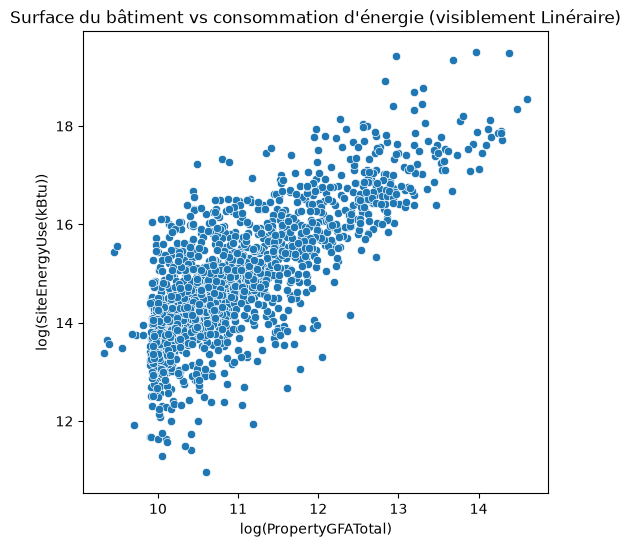

In [48]:
# Relation entre la surface du bâtiment et la consommation d'énergie
# On passe les deux axes en log, cohérent avec ce qu'on a observé sur la distribution de la target
plt.figure(figsize=(6, 6))
sns.scatterplot(
    x=np.log(building_consumption["PropertyGFATotal"]),
    y=np.log(building_consumption[target]),
)
plt.xlabel("log(PropertyGFATotal)")
plt.ylabel(f"log({target})")
plt.title("Surface du bâtiment vs consommation d'énergie (visiblement Linéraire)")
plt.show()

Corrélation assez linéaire observable

## 3.5 Typage des variables catégorielles

In [49]:
"""Nettoyage de colonnes catégorielles"""

# On force decennie_construction en texte pour qu'elle soit bien traitée comme catégorielle par OneHot
building_consumption["decennie_construction"] = building_consumption["decennie_construction"].astype(str)

# Même logique que pour decennie_construction : ce sont des identifiants de zones, pas des quantités
building_consumption["CouncilDistrictCode"] = building_consumption["CouncilDistrictCode"].astype(str)
building_consumption["ZipCode"] = building_consumption["ZipCode"].astype(str)

## 3.6 Choix de l'encodage : One-Hot plutôt que LabelEncoder, et max_categories

**Pourquoi le One-Hot plutôt que le LabelEncoder ?**

- **LabelEncoder** : un numéro par catégorie (Hôpital = 3, Bureau = 7…). Le modèle y voit un **ordre qui n'existe pas** (Bureau « plus grand » qu'Hôpital). Réservé aux catégories ordonnées.
- **One-Hot** : une colonne 0/1 par catégorie, sans ordre inventé. Adapté à nos variables (types, quartiers, codes postaux) → **choix retenu**.

`decennie_construction` a un ordre, mais son effet n'est pas régulier : le One-Hot laisse chaque décennie avoir son propre effet.

Limite du One-Hot : beaucoup de colonnes pour les variables très variées → contrôlée par `max_categories` (ci-dessous).

In [50]:
"""Méthode pour déterminer un nombre de catégories suffisant pour couvrir 90% des bâtiments"""

# Méthode : on choisit le nombre minimal de catégories qui couvre au moins 90% des bâtiments,
# Je fixe un premier seuil sur ZipCode (variable de localisation très détaillée, 48 codes postaux),
# puis je vérifie dans la cellule suivante que ce seuil convient aussi à toutes les autres variables catégorielles
seuil_couverture = 0.90

# value_counts() : nombre de bâtiments par code postal, trié du plus fréquent au moins fréquent
vc = building_consumption["ZipCode"].value_counts()

# Couverture cumulée : part des bâtiments couverts si on garde les 1, 2, 3... premiers codes postaux
# cumsum() additionne au fur et à mesure
# / vc.sum() divise par le total des bâtiments pour obtenir la proportion
couverture_cumulee = vc.cumsum() / vc.sum()

# Nombre de catégories nécessaires pour atteindre le seuil
nb_categories_necessaire = (couverture_cumulee < seuil_couverture).sum() + 1
print(f"Nombre de catégories nécessaire pour couvrir {seuil_couverture*100:.0f}% des bâtiments : {nb_categories_necessaire}")
print(f"Couverture réelle avec ce nombre : {couverture_cumulee.iloc[nb_categories_necessaire-1]*100:.1f}%")

Nombre de catégories nécessaire pour couvrir 90% des bâtiments : 18
Couverture réelle avec ce nombre : 91.2%


In [51]:
"""Effet de max_categories=18 sur chaque variable catégorielle"""
colonnes_categorielles = building_consumption.select_dtypes(include=["object", "str"]).columns.tolist()

cardinalite = pd.DataFrame({
    # Nombre de catégories différentes dans chaque variable
    "nb catégories": building_consumption[colonnes_categorielles].nunique(),
    # Part des bâtiments couverts par les 17 catégories les plus fréquentes
    # (avec max_categories=18 : 17 catégories gardées + 1 colonne "infrequent" qui regroupe les rares)
    "part couverte (17 plus fréquentes)": [
        building_consumption[col].value_counts(normalize=True).head(17).sum() for col in colonnes_categorielles
    ],
})
# Colonnes créées : autant que de catégories, plafonné à 18
cardinalite["colonnes créées"] = cardinalite["nb catégories"].clip(upper=18)

print(f"Total de colonnes créées par le One-Hot : {cardinalite['colonnes créées'].sum()}")
cardinalite.sort_values("nb catégories", ascending=False).round(2)

Total de colonnes créées par le One-Hot : 128


,nb catégories,part couverte (17 plus fréquentes),colonnes créées
LargestPropertyUseType,55,0.89,18
SecondLargestPropertyUseType,48,0.96,18
ZipCode,48,0.90,18
ThirdLargestPropertyUseType,39,0.97,18
PrimaryPropertyType,21,0.98,18
Neighborhood,14,1.00,14
decennie_construction,12,1.00,12
CouncilDistrictCode,7,1.00,7
BuildingType,5,1.00,5


**Lecture : `max_categories=18` convient à toutes les variables**

- Les 4 variables les moins variées (`Neighborhood`, `decennie_construction`, `CouncilDistrictCode`, `BuildingType`) gardent toutes leurs catégories.
- Les 5 plus variées (jusqu'à 55 catégories) sont plafonnées à 18 colonnes, mais les 17 catégories conservées couvrent **89 % à 98 % des bâtiments**. Le regroupement « infrequent » ne concerne donc que des catégories rares.
- Au total, le One-Hot crée **128 colonnes** pour 1 527 bâtiments, soit environ 12 bâtiments par colonne : un volume raisonnable pour l'apprentissage.

**À tester en modélisation** : un encodage alternatif (OrdinalEncoder) avec le Random Forest, qui supporte mieux ce type de codage, pour vérifier que le choix du One-Hot ne pénalise pas les performances.

## 3.7 Séparation X / y

In [52]:
# On sépare les features (X) de la target (y)
X = building_consumption.drop(columns=[target])
y = building_consumption[target]

print(f"Shape de X : {X.shape}")
print(f"Shape de y : {y.shape}")

Shape de X : (1527, 19)
Shape de y : (1527,)


## 3.8 Définition du préprocessing (encodage + scaling)

In [53]:
# On identifie les 2 groupes de colonnes à partir de X (pas building_consumption, pour être sûr de ne pas inclure la target)
colonnes_categorielles = X.select_dtypes(include=["object", "str"]).columns.tolist()
colonnes_numeriques = X.select_dtypes(include="number").columns.tolist()

print("Catégorielles :", colonnes_categorielles)
print("Numériques :", colonnes_numeriques)

preprocessor = ColumnTransformer(transformers=[
    ("cat", OneHotEncoder(handle_unknown="ignore", max_categories=18, sparse_output=False), colonnes_categorielles),
    ("num", StandardScaler(), colonnes_numeriques),
])

# À ce stade, le preprocessor est seulement défini
# Il sera appris (fit) uniquement sur le jeu d'entraînement, après le découpage train/test

Catégorielles : ['BuildingType', 'PrimaryPropertyType', 'ZipCode', 'CouncilDistrictCode', 'Neighborhood', 'LargestPropertyUseType', 'SecondLargestPropertyUseType', 'ThirdLargestPropertyUseType', 'decennie_construction']
Numériques : ['Latitude', 'Longitude', 'NumberofBuildings', 'NumberofFloors', 'PropertyGFATotal', 'PropertyGFAParking', 'Gas_Use', 'Steam_Use', 'Prop_Second_Use', 'Prop_Third_Use']


# 4. Comparaison de différents modèles supervisés

A réaliser :
* Pour chaque algorithme que vous allez tester, vous devez :
    * Réaliser au préalable une séparation en jeu d'apprentissage et jeu de test via une validation croisée.
    * Si les features quantitatives que vous souhaitez utiliser ont des ordres de grandeur très différents les uns des autres, et que vous utilisez un algorithme de regression qui est sensible à cette différence, alors il faut réaliser un scaling (normalisation) de la donnée au préalable.
    * Entrainer le modèle sur le jeu de Train
    * Prédire la cible sur la donnée de test (nous appelons cette étape, l'inférence).
    * Calculer les métriques de performance R2, MAE et RMSE sur le jeu de train et de test.
    * Interpréter les résultats pour juger de la fiabilité de l'algorithme.
* Vous pouvez choisir par exemple de tester un modèle linéaire, un modèle à base d'arbres et un modèle de type SVM
* Déterminer le modèle le plus performant parmi ceux testés.

In [54]:
# CODE COMPARAISON DES MODELES

## 4.1 Découpage train / test

In [55]:
'''Creation d'un jeu train test'''
# random_state fixé pour la reproductibilité (recommandation de l'étape 4)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Taille train : {X_train.shape[0]} bâtiments")
print(f"Taille test  : {X_test.shape[0]} bâtiments")

Taille train : 1221 bâtiments
Taille test  : 306 bâtiments


In [56]:
# Cible en log : définie une fois ici, utilisée dans toute la suite
y_train_log = np.log(y_train)
y_test_log = np.log(y_test)

## 4.2 Pipeline et fonction d'évaluation

**Pourquoi un Pipeline ?** Sans lui, le préprocessing (scaler, One-Hot) apprend sur tout le jeu d'entraînement *avant* la validation croisée : le pli de validation a déjà été « vu » et les scores sont trop optimistes. Le Pipeline enchaîne préprocessing et modèle : à chaque pli, le préprocessing est réappris sur les seuls plis d'entraînement. Le pli de validation reste réellement inconnu, comme un nouveau bâtiment.

**Métriques utilisées** (calculées en train et en validation, sur la cible en log) :
- **R²** : part de la variabilité de la consommation expliquée par le modèle (1 = parfait, 0 = pas mieux que prédire la moyenne). Sans unité, donc comparable entre modèles → **métrique de sélection**.
- **MAE** : erreur moyenne. En log, elle se lit comme un facteur d'erreur : une MAE de 0,5 signifie une estimation typiquement à ×1,6 ou ÷1,6 de la réalité (exp(0,5) ≈ 1,6).
- **RMSE** : pénalise davantage les grosses erreurs. Un RMSE nettement supérieur à la MAE signale quelques bâtiments très mal estimés.

**Règle de lecture** : le choix du modèle se fait sur les colonnes **valid**. Les colonnes **train** servent seulement à mesurer le sur-apprentissage (écart train − valid).

In [57]:
"""Pipeline (préprocessing + modèle) et fonction d'évaluation par validation croisée"""
from sklearn.pipeline import Pipeline

# Affichage : pas de notation scientifique, 3 décimales
pd.set_option("display.float_format", "{:,.3f}".format)

def creer_pipeline(modele, preprocessing=preprocessor):
    """Enchaîne un préprocessing (par défaut : One-Hot + StandardScaler, défini en 3.8) et le modèle."""
    return Pipeline([
        ("preprocessing", preprocessing),
        ("modele", modele),
    ])

def evaluer_modele(nom, modele, X, y, cv=5, preprocessing=preprocessor):
    """Évalue un modèle par validation croisée (5 plis), préprocessing inclus dans chaque pli."""
    scores = cross_validate(
        creer_pipeline(modele, preprocessing), X, y,
        cv=cv,
        scoring=["r2", "neg_mean_absolute_error", "neg_root_mean_squared_error"],
        return_train_score=True,        # scores train : uniquement pour mesurer le sur-apprentissage
    )
    # "-" devant les erreurs : annule le "neg_" de sklearn ; .mean() = moyenne des 5 plis
    return pd.Series({
        "R2 train":   scores["train_r2"].mean(),
        "R2 valid":   scores["test_r2"].mean(),
        "MAE train":  -scores["train_neg_mean_absolute_error"].mean(),
        "MAE valid":  -scores["test_neg_mean_absolute_error"].mean(),
        "RMSE train": -scores["train_neg_root_mean_squared_error"].mean(),
        "RMSE valid": -scores["test_neg_root_mean_squared_error"].mean(),
    }, name=nom)

## 4.3 Baseline : le seuil minimal à battre

Le `DummyRegressor` ne regarde aucune feature : il prédit **la même valeur pour tous les bâtiments**. Il répond à la question « que vaut une estimation faite sans rien savoir du bâtiment ? ». Un vrai modèle doit faire nettement mieux, sinon il n'apprend rien d'utile.

Je compare deux stratégies : prédire la **moyenne** ou la **médiane** de la consommation d'entraînement. En échelle log, la distribution est presque symétrique (cf. 1.7), donc les deux devraient donner des résultats très proches.

In [58]:
"""Baseline : deux stratégies du DummyRegressor, sur la cible en log"""
resultat_dummy_moyenne = evaluer_modele("Dummy (moyenne)", DummyRegressor(strategy="mean"), X_train, y_train_log)
resultat_dummy_mediane = evaluer_modele("Dummy (médiane)", DummyRegressor(strategy="median"), X_train, y_train_log)

pd.DataFrame([resultat_dummy_moyenne, resultat_dummy_mediane])

,R2 train,R2 valid,MAE train,MAE valid,RMSE train,RMSE valid
Dummy (moyenne),0.000,-0.004,1.032,1.032,1.290,1.290
Dummy (médiane),-0.011,-0.015,1.026,1.026,1.298,1.297


**Lecture de la baseline**

- **R² ≈ 0** : attendu par construction, prédire une valeur unique n'explique aucune différence entre bâtiments.
- **MAE ≈ 1,03 (log)** : sans rien savoir d'un bâtiment, l'estimation est typiquement **2,8 fois trop haute ou trop basse** (exp(1,03) ≈ 2,8). C'est le niveau d'erreur que les vrais modèles doivent battre.
- **Moyenne ou médiane ?** Les deux stratégies sont quasi équivalentes. Chacune gagne de peu sur « sa » métrique : la médiane minimise l'erreur absolue (MAE légèrement meilleure), la moyenne l'erreur au carré (R² et RMSE légèrement meilleurs).

**Choix : la moyenne** comme baseline de référence. Elle correspond exactement au point zéro du R², la métrique de sélection des modèles.

## 4.4 Comparaison sur la cible brute

In [59]:
"""Comparaison des modèles sur la cible BRUTE (kBtu), à titre de référence"""
modeles = {
    "Dummy (moyenne)": DummyRegressor(strategy="mean"),
    "Régression linéaire": LinearRegression(),
    "SVR": SVR(),
    "Random Forest": RandomForestRegressor(random_state=42),
}

# Même fonction, mêmes plis, mêmes métriques pour chaque modèle -> comparaison équitable
comparaison_brute = pd.DataFrame([evaluer_modele(nom, m, X_train, y_train) for nom, m in modeles.items()])
comparaison_brute

,R2 train,R2 valid,MAE train,MAE valid,RMSE train,RMSE valid
Dummy (moyenne),0.000,-0.004,"8,221,781.121","8,228,022.112","19,195,044.700","19,006,204.841"
Régression linéaire,0.731,0.520,"5,073,585.554","6,051,753.060","9,938,300.709","12,615,379.098"
SVR,-0.072,-0.077,"6,504,475.743","6,504,151.043","19,877,015.656","19,677,524.382"
Random Forest,0.955,0.693,"1,382,704.309","3,632,490.913","4,065,301.747","10,049,057.647"


**Lecture : la cible brute pénalise fortement certains modèles**

- **Le SVR fait moins bien que la baseline** (R² = −0,08) : face à des consommations allant de quelques dizaines de milliers à plusieurs centaines de millions de kBtu, il ne parvient pas à apprendre et prédit quasiment la même valeur pour tous.
- **Le Random Forest s'en sort le mieux** (R² valid = 0,69), car il découpe les données par seuils, ce qui le rend moins sensible aux ordres de grandeur.
- **Les erreurs en kBtu sont dominées par les très gros bâtiments** : la MAE du Random Forest (3,6 M kBtu) dépasse la consommation d'un bâtiment médian (2,7 M).

→ Ces résultats confirment l'intérêt de **modéliser la cible en log** (cf. 1.7), testé ci-dessous.

## 4.5 Comparaison sur la cible en log, puis choix du modèle

In [60]:
"""Comparaison des modèles sur la cible en LOG"""
# Mêmes modèles (dictionnaire défini en 4.4), seule la cible change
comparaison_log = pd.DataFrame([evaluer_modele(nom, m, X_train, y_train_log) for nom, m in modeles.items()])

# Écart train - valid : mesure du sur-apprentissage (plus il est grand, plus le modèle "apprend par cœur")
comparaison_log["Écart R2 (train - valid)"] = comparaison_log["R2 train"] - comparaison_log["R2 valid"]

# Tri sur le R2 de VALIDATION : c'est lui, et lui seul, qui sert à choisir le modèle
comparaison_log.sort_values("R2 valid", ascending=False)

,R2 train,R2 valid,MAE train,MAE valid,RMSE train,RMSE valid,Écart R2 (train - valid)
Random Forest,0.960,0.705,0.194,0.526,0.259,0.699,0.255
SVR,0.824,0.665,0.360,0.564,0.541,0.745,0.159
Régression linéaire,0.691,0.590,0.559,0.639,0.718,0.824,0.101
Dummy (moyenne),0.000,-0.004,1.032,1.032,1.290,1.290,0.004


**Choix du modèle**

Le choix se fait **uniquement sur les scores de validation** (bâtiments non vus pendant l'entraînement du pli). Les scores d'entraînement servent seulement à mesurer le sur-apprentissage.

- **Le passage en log profite à tous les modèles**, en particulier au SVR (R² valid de −0,08 à 0,67).
- **Le Random Forest est le meilleur sur les trois métriques de validation** : R² = 0,705, MAE = 0,526, RMSE = 0,699. Sa MAE signifie une estimation typiquement à ×1,7 ou ÷1,7 de la consommation réelle (exp(0,526) ≈ 1,7), contre ×2,8 pour la baseline.
- Le **SVR** suit (R² = 0,665), la **régression linéaire** est derrière (R² = 0,590). Tous battent largement la baseline.

**Point de vigilance : le Random Forest sur-apprend le plus** (écart train − valid de 0,26, contre 0,16 pour le SVR et 0,10 pour la régression linéaire) : il « apprend par cœur » une partie des bâtiments d'entraînement.

**Suite** : je retiens le Random Forest et tente de réduire ce sur-apprentissage par une GridSearch (partie 5). Son avance sur le SVR étant modérée, j'optimiserai aussi le SVR pour vérifier qu'il reste devant après réglage.

## 4.6 Challenger l'encodage : One-Hot ou OrdinalEncoder pour le Random Forest ?

Le One-Hot a été choisi en 3.6 car l'OrdinalEncoder invente un ordre entre catégories : c'est un vrai problème pour un modèle linéaire. Un Random Forest, lui, découpe les données par seuils successifs et peut isoler une catégorie malgré l'ordre artificiel. Je compare donc les deux encodages avec le Random Forest, sur les mêmes plis.

In [61]:
"""Même Random Forest, deux encodages différents"""
from sklearn.preprocessing import OrdinalEncoder

# Préprocessing alternatif :
# - OrdinalEncoder : un numéro par catégorie (1 colonne par variable, au lieu de jusqu'à 18 avec le One-Hot)
#   handle_unknown / unknown_value : une catégorie absente des plis d'entraînement reçoit -1 au lieu de faire planter
# - "passthrough" : numériques laissées telles quelles (un Random Forest n'a pas besoin de scaling)
preprocessor_ordinal = ColumnTransformer(transformers=[
    ("cat", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1), colonnes_categorielles),
    ("num", "passthrough", colonnes_numeriques),
])

comparaison_encodage = pd.DataFrame([
    evaluer_modele("RF + One-Hot", RandomForestRegressor(random_state=42), X_train, y_train_log),
    evaluer_modele("RF + OrdinalEncoder", RandomForestRegressor(random_state=42), X_train, y_train_log,
                   preprocessing=preprocessor_ordinal),
])
comparaison_encodage

,R2 train,R2 valid,MAE train,MAE valid,RMSE train,RMSE valid
RF + One-Hot,0.960,0.705,0.194,0.526,0.259,0.699
RF + OrdinalEncoder,0.959,0.709,0.196,0.520,0.261,0.694


**Lecture : les deux encodages sont équivalents pour le Random Forest**

- L'OrdinalEncoder obtient un R² de validation très légèrement supérieur (0,709 contre 0,705). Cet écart de 0,004 est trop faible pour être significatif : un autre découpage des plis pourrait l'inverser.
- Cela confirme qu'un modèle à arbres n'est **pas pénalisé** par l'ordre artificiel de l'OrdinalEncoder, contrairement à un modèle linéaire.

**Décision : je conserve le One-Hot.** C'est le seul encodage valable pour tous les modèles comparés (régression linéaire et SVR compris), ce qui garantit une comparaison équitable avec un préprocessing identique. Changer d'encodage pour un gain non significatif n'apporterait rien.

# 5. Optimisation et interprétation du modèle

A réaliser :
* Reprennez le meilleur algorithme que vous avez sécurisé via l'étape précédente, et réalisez une GridSearch de petite taille sur au moins 3 hyperparamètres.
* Si le meilleur modèle fait partie de la famille des modèles à arbres (RandomForest, GradientBoosting) alors utilisez la fonctionnalité feature importance pour identifier les features les plus impactantes sur la performance du modèle. Sinon, utilisez la méthode Permutation Importance de sklearn.

In [62]:
# CODE OPTIMISATION ET INTERPRETATION DU MODELE

## 5.1 GridSearch de test sur RF (petite grille)

In [63]:
"""GridSearch de test (petite grille) sur le pipeline Random Forest"""
# Petite grille pour vérifier que le code fonctionne avant de passer à grande échelle
# Préfixe "modele__" : le paramètre s'applique à l'étape "modele" du pipeline (2 tirets bas)
petite_grille = {
    "modele__n_estimators": [50, 100],
    "modele__max_depth": [5, 10, None],    # None = pas de limite (comportement par défaut)
    "modele__min_samples_leaf": [1, 5],
}
# 2 x 3 x 2 = 12 combinaisons

grid_search_test = GridSearchCV(
    creer_pipeline(RandomForestRegressor(random_state=42)),   # le pipeline entier, pas le modèle seul
    param_grid=petite_grille,
    cv=5,
    scoring="r2",       # métrique de sélection, cf. 4.2
    n_jobs=-1,          # utilise tous les cœurs du processeur
)

grid_search_test.fit(X_train, y_train_log)   # données brutes : le pipeline fait le préprocessing

print(f"Meilleurs paramètres : {grid_search_test.best_params_}")
print(f"Meilleur score (R2, validation croisée) : {grid_search_test.best_score_:.3f}")

Meilleurs paramètres : {'modele__max_depth': None, 'modele__min_samples_leaf': 1, 'modele__n_estimators': 100}
Meilleur score (R2, validation croisée) : 0.705


Le code fonctionne sur 12 combinaisons. Meilleurs paramètres : max_depth = None, min_samples_leaf = 1, n_estimators = 100 (les valeurs par défaut).  
R² en validation croisée = 0,705, identique au Random Forest par défaut (cf. 4.5).  
Je lance donc une grille plus large pour voir si un autre réglage fait mieux.

## 5.2 GridSearch élargie sur RF

In [64]:
"""GridSearch élargie sur le pipeline Random Forest (4 hyperparamètres)"""
grille_elargie = {
    "modele__n_estimators": [100, 300],
    "modele__max_depth": [10, 20, None],
    "modele__min_samples_leaf": [1, 2, 5],
    # Part des features examinées à chaque découpage : 1.0 = toutes (défaut), "sqrt" = racine carrée du nombre
    # -> moins de features par découpage = arbres plus variés = souvent moins de sur-apprentissage
    "modele__max_features": [1.0, 0.5, 0.3, "sqrt"],
}
# 2 x 3 x 3 x 4 = 72 combinaisons x 5 plis = 360 entraînements -> quelques minutes

grid_search_rf = GridSearchCV(
    creer_pipeline(RandomForestRegressor(random_state=42)),
    param_grid=grille_elargie,
    cv=5,
    scoring="r2",
    n_jobs=-1,
    return_train_score=True,   # pour pouvoir mesurer le sur-apprentissage de chaque combinaison
)

grid_search_rf.fit(X_train, y_train_log)

print(f"Meilleurs paramètres : {grid_search_rf.best_params_}")
print(f"Meilleur score (R2, validation croisée) : {grid_search_rf.best_score_:.3f}")

Meilleurs paramètres : {'modele__max_depth': None, 'modele__max_features': 0.3, 'modele__min_samples_leaf': 1, 'modele__n_estimators': 100}
Meilleur score (R2, validation croisée) : 0.729


**Résultat de la grille élargie**

- Meilleurs paramètres : `max_features = 0.3`, `max_depth = None`, `min_samples_leaf = 1`, `n_estimators = 100`.
- **R² en validation croisée : 0,705 → 0,729**, un gain réel cette fois.
- **Le gain vient de `max_features`** : chaque découpage n'examine que 30 % des features, tirées au hasard. Les arbres ne s'appuient plus tous sur la surface, ils deviennent plus variés, et leur moyenne généralise mieux. Les trois autres paramètres restent à leur valeur par défaut : brider les arbres n'aidait pas.
- **L'optimum est bien encadré** : 0,3 se situe entre 0,5 et `"sqrt"` (≈ 0,09 ici : √138 ≈ 12 features sur les 138 colonnes obtenues après préprocessing), et `min_samples_leaf = 1` est déjà la valeur minimale.

In [65]:
"""Le sur-apprentissage a-t-il baissé ? Comparaison avant / après GridSearch, sur les MÊMES plis"""
# best_params_ contient "modele__max_features"... : on retire le préfixe pour les passer au RandomForestRegressor
# (le préfixe ne sert qu'à la GridSearch, pour savoir à quelle étape du pipeline appliquer le paramètre)
params_rf_optimise = {nom.replace("modele__", ""): valeur for nom, valeur in grid_search_rf.best_params_.items()}

comparaison_rf = pd.DataFrame([
    evaluer_modele("RF par défaut", RandomForestRegressor(random_state=42), X_train, y_train_log),
    evaluer_modele("RF optimisé", RandomForestRegressor(**params_rf_optimise, random_state=42), X_train, y_train_log),
])
comparaison_rf["Écart R2 (train - valid)"] = comparaison_rf["R2 train"] - comparaison_rf["R2 valid"]
comparaison_rf[["R2 train", "R2 valid", "MAE valid", "Écart R2 (train - valid)"]]

,R2 train,R2 valid,MAE valid,Écart R2 (train - valid)
RF par défaut,0.960,0.705,0.526,0.255
RF optimisé,0.962,0.729,0.505,0.233


**Le sur-apprentissage a-t-il baissé ?**

Comparaison des deux versions du Random Forest, sur les mêmes plis :
- **R² valid : 0,705 → 0,729** et **MAE valid : 0,526 → 0,505**.
- **Écart train − valid : 0,255 → 0,233** : le sur-apprentissage baisse modérément.
- Cette baisse vient de la **hausse du score de validation**, pas d'une baisse du score d'entraînement, qui reste à 0,96. Un Random Forest à arbres non bridés reproduit presque parfaitement ses données d'entraînement : c'est dans sa nature. L'important est qu'il généralise mieux sur des bâtiments non vus.

Le sur-apprentissage reste présent, mais l'optimisation l'a réduit tout en améliorant la performance.

## 5.3 Contre-vérification avec le SVR (petite grille)

In [66]:
"""Contre-vérification : le SVR optimisé rattrape-t-il le Random Forest ?"""
# Même préfixe "modele__" que pour le Random Forest
# (le scaling, indispensable au SVR, est assuré par le StandardScaler du pipeline)
petite_grille_svr = {
    "modele__C": [1, 10, 50],              # tolérance aux erreurs : plus C est grand, plus le modèle colle aux données
    "modele__epsilon": [0.01, 0.1, 0.5],   # marge d'erreur ignorée autour de la prédiction
    "modele__kernel": ["rbf", "linear"],   # forme de la relation : courbe (rbf) ou droite (linear)
}
# 3 x 3 x 2 = 18 combinaisons

grid_search_svr = GridSearchCV(
    creer_pipeline(SVR()),
    param_grid=petite_grille_svr,
    cv=5,
    scoring="r2",
    n_jobs=-1,
)

grid_search_svr.fit(X_train, y_train_log)

print(f"Meilleurs paramètres SVR : {grid_search_svr.best_params_}")
print(f"Meilleur score SVR (R2, validation croisée) : {grid_search_svr.best_score_:.3f}")

Meilleurs paramètres SVR : {'modele__C': 1, 'modele__epsilon': 0.01, 'modele__kernel': 'rbf'}
Meilleur score SVR (R2, validation croisée) : 0.667


**Choix final du modèle**

| Modèle | R² validation croisée (par défaut → optimisé) |
|---|---|
| Random Forest | 0,705 → **0,729** |
| SVR | 0,665 → 0,667 |

- L'optimisation n'apporte presque rien au SVR, alors qu'elle fait progresser le Random Forest grâce à `max_features`.
- Les meilleures valeurs du SVR sont en bord de grille (`C = 1`, `epsilon = 0,01`, les plus petites testées). Une grille plus fine reste possible, mais l'écart avec le Random Forest (plus de 0,06) est trop important pour être comblé par un réglage.

**Je retiens le Random Forest optimisé** pour l'évaluation finale sur le jeu de test (5.4) et l'interprétation (5.5).

## 5.4 Évaluation sur le jeu de test

In [67]:
"""Évaluation finale sur le jeu de test : première et unique utilisation"""
# best_estimator_ = le pipeline complet (préprocessing + Random Forest optimisé),
# déjà réentraîné par GridSearchCV sur tout X_train avec les meilleurs paramètres
meilleur_rf = grid_search_rf.best_estimator_

# Prédictions (en log) : le pipeline applique lui-même le préprocessing appris sur X_train
y_pred_train_log = meilleur_rf.predict(X_train)
y_pred_test_log = meilleur_rf.predict(X_test)

print(f"R2 train : {r2_score(y_train_log, y_pred_train_log):.3f}")
print(f"R2 test  : {r2_score(y_test_log, y_pred_test_log):.3f}  (validation croisée : {grid_search_rf.best_score_:.3f})")
print(f"MAE test (log) : {mean_absolute_error(y_test_log, y_pred_test_log):.3f}")

R2 train : 0.963
R2 test  : 0.710  (validation croisée : 0.729)
MAE test (log) : 0.524


**Lecture des résultats sur le jeu de test**

- **R² test = 0,710**, proche du R² de validation croisée (0,729) : le modèle généralise comme prévu sur 306 bâtiments jamais vus, ni pendant l'entraînement, ni pendant le réglage. L'écart de 0,02 reflète simplement la composition du jeu de test, avec des bâtiments plus ou moins faciles à estimer.
- **MAE test = 0,524** (0,505 en validation croisée) : cohérente.
- **R² train = 0,963** : le sur-apprentissage identifié en 5.2 est toujours présent.

Ce score est définitif : le jeu de test n'est utilisé qu'une seule fois. Modifier le modèle après l'avoir vu reviendrait à l'optimiser sur le test, qui ne mesurerait alors plus la performance réelle.

## 5.5 Feature importance

In [68]:
"""Feature importance du Random Forest optimisé"""
# named_steps["..."] : accès à une étape du pipeline par son nom (défini dans creer_pipeline)
# - noms des colonnes : produits par l'étape "preprocessing" (One-Hot + scaler)
# - importances : calculées par l'étape "modele" (le Random Forest)
noms_colonnes = meilleur_rf.named_steps["preprocessing"].get_feature_names_out()
importances_rf = meilleur_rf.named_steps["modele"].feature_importances_

importances = pd.DataFrame({
    "feature": noms_colonnes,
    "importance": importances_rf,
}).sort_values("importance", ascending=False)

print(f"Nombre de features : {len(noms_colonnes)}")
importances.head(15)

Nombre de features : 138


,feature,importance
132,num__PropertyGFATotal,0.389
131,num__NumberofFloors,0.135
133,num__PropertyGFAParking,0.046
128,num__Latitude,0.030
129,num__Longitude,0.027
67,cat__LargestPropertyUseType_Non-Refrigerated W...,0.023
18,cat__PrimaryPropertyType_Supermarket / Grocery...,0.023
134,num__Gas_Use,0.022
20,cat__PrimaryPropertyType_Warehouse,0.019
136,num__Prop_Second_Use,0.017


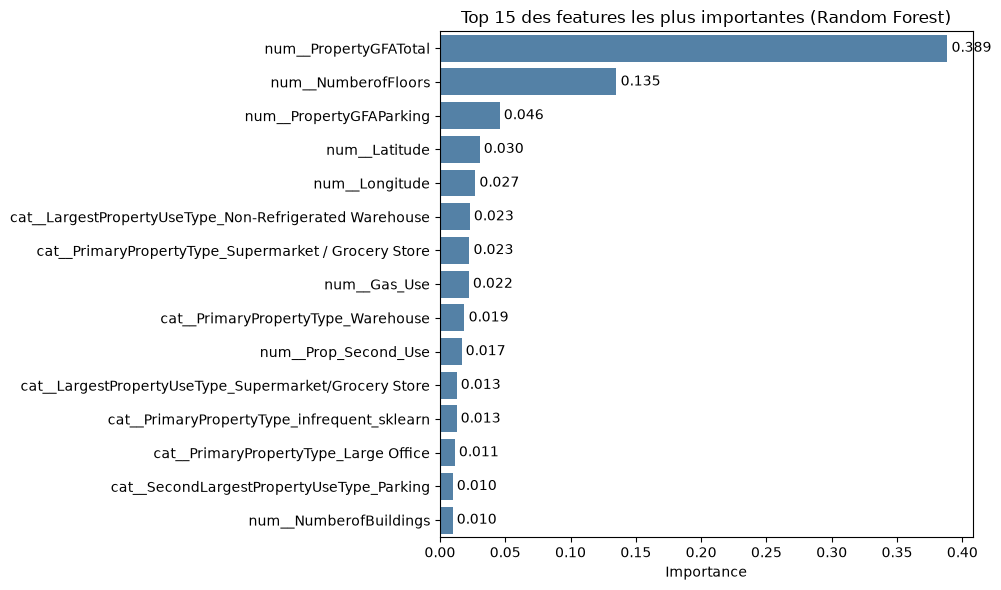

In [69]:
top_n = 15

plt.figure(figsize=(10, 6))
ax = sns.barplot(data=importances.head(top_n), x="importance", y="feature", color="steelblue")

# Affiche la valeur au bout de chaque barre (3 décimales, petit décalage pour ne pas toucher la barre)
ax.bar_label(ax.containers[0], fmt="%.3f", padding=3)

plt.title(f"Top {top_n} des features les plus importantes (Random Forest)")
plt.xlabel("Importance")
plt.ylabel("")
plt.tight_layout()
plt.show()

**Lecture des feature importances (colonne par colonne)**

- **La surface totale reste le 1er facteur** (0,389), suivie du **nombre d'étages** (0,135), qui la complète : il distingue un bâtiment bas et étendu (entrepôt) d'une tour compacte (bureaux).
- **Les catégories d'usage qui ressortent correspondent aux extrêmes vus en 1.9** : entrepôts (sobres), supermarchés (gourmands en froid alimentaire), grands bureaux.
- **Deux features créées en partie 2 apparaissent dans le top 15** : `Gas_Use` (0,022) et `Prop_Second_Use` (0,017).
- **L'importance est mieux répartie qu'avec le modèle par défaut** : avec `max_features = 0.3`, la surface n'est disponible qu'à environ un découpage sur trois, et les arbres s'appuient alors aussi sur d'autres variables.

**Limite de cette méthode** : le One-Hot **éclate chaque variable catégorielle** en plusieurs colonnes (une par catégorie). Le poids total d'une variable comme `PrimaryPropertyType` est donc dispersé et paraît plus faible qu'il ne l'est → regroupement ci-dessous.

Je regroupe à nouveau les catégories explosées par le one-hot

variable
PropertyGFATotal               0.389
NumberofFloors                 0.135
PrimaryPropertyType            0.107
LargestPropertyUseType         0.079
PropertyGFAParking             0.046
Latitude                       0.030
decennie_construction          0.029
Longitude                      0.027
ZipCode                        0.026
SecondLargestPropertyUseType   0.025
Gas_Use                        0.022
Neighborhood                   0.019
Prop_Second_Use                0.017
CouncilDistrictCode            0.012
NumberofBuildings              0.010
ThirdLargestPropertyUseType    0.009
BuildingType                   0.009
Prop_Third_Use                 0.008
Steam_Use                      0.002
Name: importance, dtype: float64


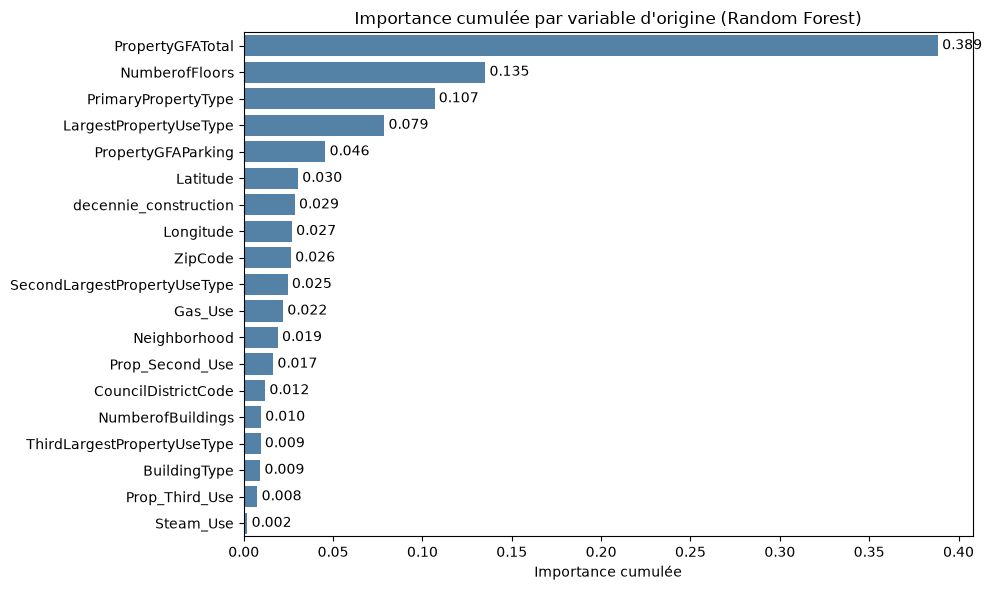

In [70]:
"""Feature importance regroupée par variable d'origine"""
# Le One-Hot a éclaté chaque variable catégorielle en plusieurs colonnes (une par catégorie).
# On retrouve pour chaque colonne sa variable d'origine, puis on additionne les importances.

def variable_origine(nom_colonne):
    """Retrouve la variable d'origine à partir du nom de colonne après transformation."""
    # Colonnes catégorielles : "cat__LargestPropertyUseType_Office" -> "LargestPropertyUseType"
    for col in colonnes_categorielles:
        if nom_colonne.startswith(f"cat__{col}_"):
            return col
    # Colonnes numériques : "num__PropertyGFATotal" -> "PropertyGFATotal"
    return nom_colonne.replace("num__", "")

importances["variable"] = importances["feature"].apply(variable_origine)

# Somme des importances par variable d'origine, de la plus importante à la moins importante
importances_par_variable = (
    importances.groupby("variable")["importance"]
    .sum()
    .sort_values(ascending=False)
)
print(importances_par_variable)

# Même graphique que précédemment, mais par variable d'origine
plt.figure(figsize=(10, 6))
ax = sns.barplot(x=importances_par_variable.values, y=importances_par_variable.index, color="steelblue")

# Affiche la valeur au bout de chaque barre
ax.bar_label(ax.containers[0], fmt="%.3f", padding=3)

plt.title("Importance cumulée par variable d'origine (Random Forest)")
plt.xlabel("Importance cumulée")
plt.ylabel("")
plt.tight_layout()
plt.show()

**Lecture des importances regroupées par variable d'origine**

Une fois les colonnes One-Hot réassemblées, les variables catégorielles, dont le poids était dispersé, remontent nettement : `PrimaryPropertyType` passe 3e (0,107) et `LargestPropertyUseType` 4e (0,079).

| Famille | Variables | Importance cumulée |
|---|---|---|
| **Taille** | surface, étages, parking, nombre de bâtiments | **≈ 58 %** |
| **Usage** | types d'usage (principal, 2e, 3e, BuildingType), proportions d'usages | **≈ 25 %** |
| **Localisation** | latitude, longitude, code postal, quartier, district | **≈ 11 %** |
| **Temporalité** | `decennie_construction` | ≈ 3 % |
| **Sources d'énergie** | `Gas_Use`, `Steam_Use` | ≈ 2 % |

**Ce qu'on retient :**
- **La taille est le 1er facteur**, portée par la surface totale et le nombre d'étages.
- **L'usage est un facteur majeur** (un quart de l'importance) : à surface égale, un supermarché ou un hôpital ne consomme pas comme un entrepôt.
- **La localisation joue un rôle secondaire** : elle ne ressortait pas dans les corrélations (cf. 1.9), mais le modèle la capte par zones.
- **Les features créées en partie 2 pèsent environ 8 % au total** (décennie, gaz, vapeur, proportions d'usages). Elles apportent une information utile, sans dominer.

**Conclusion :** la consommation d'un bâtiment s'explique d'abord par sa taille, ensuite par ce qu'on y fait, et dans une moindre mesure par l'endroit où il se trouve.

## 5.6 Traduction métier (kBtu, erreur relative)

In [71]:
"""On repasse en unité réelles hors du log"""
# Prédictions du modèle optimisé (encore en log)
y_pred_log = meilleur_rf.predict(X_test)   # données brutes : le pipeline fait le préprocessing

# Reconversion en vraies unités (kBtu)
y_pred_reel = np.exp(y_pred_log)

# Métriques finales, directement comparables aux vraies valeurs de consommation
mae_reel = mean_absolute_error(y_test, y_pred_reel)
rmse_reel = mean_squared_error(y_test, y_pred_reel) ** 0.5
r2_reel = r2_score(y_test, y_pred_reel)

print(f"MAE (kBtu) : {mae_reel:,.0f}")
print(f"RMSE (kBtu) : {rmse_reel:,.0f}")
print(f"R2 (échelle réelle) : {r2_reel:.3f}")

MAE (kBtu) : 4,158,834
RMSE (kBtu) : 16,150,052
R2 (échelle réelle) : 0.313


In [72]:
# Erreur relative par bâtiment, en % : chaque bâtiment compte "à égalité", contrairement au MAE
erreur_relative = (y_test - y_pred_reel).abs() / y_test * 100
print(f"Erreur relative médiane : {erreur_relative.median():.1f}%")
print(f"Erreur relative moyenne : {erreur_relative.mean():.1f}%")

# Part des bâtiments par tranche d'erreur
tranches = pd.cut(erreur_relative, [0, 10, 25, 50, 100, float("inf")], right=False)
print(tranches.value_counts(sort=False, normalize=True).round(3))

Erreur relative médiane : 35.8%
Erreur relative moyenne : 59.6%
SiteEnergyUse(kBtu)
[0.0, 10.0)     0.157
[10.0, 25.0)    0.206
[25.0, 50.0)    0.281
[50.0, 100.0)   0.216
[100.0, inf)    0.141
Name: proportion, dtype: float64


In [73]:
"""Quels bâtiments concentrent l'erreur en kBtu ?"""
erreurs = pd.DataFrame({
    "type": X_test["PrimaryPropertyType"],
    "conso réelle": y_test,
    "conso prédite": y_pred_reel,
    "erreur absolue": (y_test - y_pred_reel).abs(),
}).sort_values("erreur absolue", ascending=False)

# Part de l'erreur totale portée par les 5 plus grosses erreurs (sur 306 bâtiments)
part_top5 = erreurs["erreur absolue"].head(5).sum() / erreurs["erreur absolue"].sum()
print(f"Les 5 plus grosses erreurs représentent {part_top5:.0%} de l'erreur totale en kBtu")
erreurs.head(5)

Les 5 plus grosses erreurs représentent 34% de l'erreur totale en kBtu


,type,conso réelle,conso prédite,erreur absolue
558,Other,"274,682,208.000","29,032,197.568","245,650,010.432"
559,Large Office,"92,937,640.000","42,343,874.537","50,593,765.463"
329,Other,"61,762,380.000","14,387,305.416","47,375,074.584"
474,Mixed Use Property,"63,835,192.000","16,761,398.097","47,073,793.903"
3277,University,"51,168,308.000","9,444,543.784","41,723,764.216"


**Traduction des performances en langage métier**

**L'erreur relative, la mesure la plus parlante**
En mesurant l'écart en % de la consommation réelle, chaque bâtiment compte à égalité, quelle que soit sa taille :
- **Erreur médiane de 36 %** : pour un bâtiment typique, l'estimation s'écarte d'environ un tiers de sa consommation réelle.
- **2 bâtiments sur 3** (64 %) sont estimés à moins de 50 % près, et plus d'**1 sur 3** (36 %) à moins de 25 %.
- **1 bâtiment sur 7** (14 %) est très mal estimé (erreur > 100 %), ce qui tire la moyenne vers le haut (60 % contre 36 % pour la médiane).

**Pourquoi les métriques en kBtu sont mauvaises (MAE 4,2 M, R² 0,31)**
- **5 bâtiments sur 306 portent 34 % de l'erreur totale.** Tous sont de très gros consommateurs, fortement sous-estimés (jusqu'à 9 fois moins que la réalité).
- Ce sont des bâtiments à **très forte intensité énergétique**, dont l'activité réelle (laboratoires, informatique, process…) n'apparaît pas dans les données structurelles. Le modèle prédit la consommation d'un bâtiment « normal » de même taille et de même type.
- En kBtu, une seule erreur sur un tel bâtiment pèse plus que les erreurs de dizaines de petits bâtiments. Le modèle, entraîné en log, minimise des erreurs **relatives**, pas absolues.
- Ces bâtiments ont été **volontairement conservés** (cf. 3.3) : les retirer aurait artificiellement amélioré ces scores.

**Conclusion :** le modèle donne un **bon ordre de grandeur** pour la majorité des bâtiments. Il est utile pour **prioriser** les relevés, mais pas pour **remplacer** une mesure. Il reste aveugle aux activités très énergivores, invisibles dans les données structurelles : ce sont précisément ces bâtiments qu'un relevé réel doit vérifier.